# Bahdanau RNNsearch EN-to-BN Colab Notebook

This notebook is a standalone Colab version of the project for English-to-Bengali translation. It writes the full PyTorch package, sample data, configs, docs, and tests into `/content/bahdanau_rnnsearch`, installs the package, fetches English/Bengali parallel data from Hugging Face, trains the model, runs English-to-Bengali inference, and evaluates BLEU.

Use **Runtime -> Change runtime type -> GPU** in Colab for larger datasets. The quick defaults are intentionally modest so the full pipeline can run in Colab.


## 1. Materialize The Project

Run this cell first. It recreates the repository from the sources embedded in this notebook.


In [1]:
from pathlib import Path
import shutil

PROJECT_DIR = Path("/content/bahdanau_rnnsearch") if Path("/content").exists() else (Path.cwd() / "bahdanau_rnnsearch_colab_runtime")
OVERWRITE_PROJECT = True

PROJECT_FILES = {
    '.gitignore': '.venv/\n__pycache__/\n.pytest_cache/\nruns/\n*.pt\n*.png\n',
    'README.md': "# Bahdanau RNNsearch: end-to-end implementation\n\nThis is a self-contained PyTorch implementation of Bahdanau, Cho, and Bengio's **Neural Machine Translation by Jointly Learning to Align and Translate**. It includes the model, training loop, length-bucket batching, Adadelta + gradient clipping, beam-search decoding, tokenized BLEU, and attention heatmap visualization.\n\nThe implementation follows the paper's RNNsearch design: a bidirectional recurrent encoder produces one annotation per source token; the decoder computes a fresh context vector for every target token with additive soft attention; and the output distribution is computed through a maxout hidden layer before the final softmax.\n\n## What is included\n\n```text\nsrc/rnnsearch/\n  model.py              # encoder, decoder GRU, additive attention, maxout output layer\n  train.py              # end-to-end training CLI\n  translate.py          # beam-search translation CLI\n  evaluate.py           # corpus evaluation CLI with dependency-free BLEU\n  inference.py          # reusable greedy/beam decoding functions\n  data.py               # TSV loading, vocabulary numericalization, length buckets\n  vocab.py              # special-token-safe vocabulary\n  plot_attention.py     # Figure-3-style attention visualization\n  checkpoint.py         # save/load model + vocab + config\nconfigs/\n  tiny.sh               # small CPU smoke settings\n  paper_like_30.sh      # approximate RNNsearch-30 hyperparameters\n  paper_like_50.sh      # approximate RNNsearch-50 hyperparameters\ndata/tiny/\n  train.tsv dev.tsv test.tsv\nscripts/quickstart.sh   # train, translate, evaluate, and save an attention image\n```\n\n## Install\n\nFrom the repository root:\n\n```zsh\npython -m venv .venv\nsource .venv/bin/activate\npython -m pip install --upgrade pip\npython -m pip install -e '.[dev]'\n```\n\nThe runtime dependency is PyTorch. `matplotlib` is included for attention plots, and `pytest` is included in the `dev` extra. For tiny CPU demos, setting `OMP_NUM_THREADS=1` or passing `--torch-threads 1` avoids thread-pool overhead from many small recurrent operations.\n\n## Run the full tiny pipeline\n\n```zsh\n./scripts/quickstart.sh\n```\n\nThat runs training on the tiny corpus, translates one sentence, evaluates the tiny test set, and writes:\n\n```text\nruns/tiny/best.pt\nruns/tiny/last.pt\nruns/tiny/src_vocab.json\nruns/tiny/tgt_vocab.json\nruns/tiny/test.pred.txt\nruns/tiny/attention.png\n```\n\nEquivalent explicit commands:\n\n```zsh\nOMP_NUM_THREADS=1 PYTHONPATH=src python -m rnnsearch.train \\\n  --train data/tiny/train.tsv \\\n  --dev data/tiny/dev.tsv \\\n  --save-dir runs/tiny \\\n  --emb-dim 32 \\\n  --hidden-dim 32 \\\n  --align-dim 32 \\\n  --maxout-dim 32 \\\n  --batch-size 8 \\\n  --epochs 400 \\\n  --report-every 400 \\\n  --epoch-report-every 25 \\\n  --eval-every 100 \\\n  --device cpu \\\n  --torch-threads 1\n\nOMP_NUM_THREADS=1 PYTHONPATH=src python -m rnnsearch.translate \\\n  --checkpoint runs/tiny/best.pt \\\n  --sentence 'i like cats' \\\n  --beam-size 3 \\\n  --device cpu \\\n  --attention-png runs/tiny/attention.png\n\nOMP_NUM_THREADS=1 PYTHONPATH=src python -m rnnsearch.evaluate \\\n  --checkpoint runs/tiny/best.pt \\\n  --test data/tiny/test.tsv \\\n  --beam-size 3 \\\n  --device cpu \\\n  --predictions runs/tiny/test.pred.txt\n```\n\n## Train on your own parallel corpus\n\nCreate UTF-8 TSV files with one tokenized pair per line:\n\n```text\nsource tokens separated by spaces<TAB>target tokens separated by spaces\n```\n\nThen run:\n\n```zsh\nPYTHONPATH=src python -m rnnsearch.train \\\n  --train path/to/train.tsv \\\n  --dev path/to/dev.tsv \\\n  --save-dir runs/my_run \\\n  --src-vocab-size 30000 \\\n  --tgt-vocab-size 30000 \\\n  --max-src-len 50 \\\n  --max-tgt-len 50 \\\n  --emb-dim 620 \\\n  --hidden-dim 1000 \\\n  --align-dim 1000 \\\n  --maxout-dim 500 \\\n  --batch-size 80 \\\n  --lr 1.0 \\\n  --rho 0.95 \\\n  --eps 0.000001 \\\n  --clip-norm 1.0 \\\n  --device cuda\n```\n\nThe paper-like config files are argument fragments; you can use them with `xargs` from zsh/bash:\n\n```zsh\nPYTHONPATH=src python -m rnnsearch.train \\\n  --train path/to/train.tsv \\\n  --dev path/to/dev.tsv \\\n  --save-dir runs/rnnsearch50 \\\n  $(grep -v '^#' configs/paper_like_50.sh | xargs) \\\n  --device cuda\n```\n\n## Translate a file\n\n```zsh\nPYTHONPATH=src python -m rnnsearch.translate \\\n  --checkpoint runs/my_run/best.pt \\\n  --input path/to/source.txt \\\n  --output runs/my_run/translations.txt \\\n  --beam-size 12 \\\n  --max-len 120 \\\n  --device cuda\n```\n\nFor a single sentence with an alignment plot:\n\n```zsh\nPYTHONPATH=src python -m rnnsearch.translate \\\n  --checkpoint runs/my_run/best.pt \\\n  --sentence 'the agreement on the european economic area was signed in august 1992 .' \\\n  --beam-size 12 \\\n  --attention-png runs/my_run/alignment.png \\\n  --device cuda\n```\n\n## Test\n\n```zsh\nPYTHONPATH=src pytest -q\n```\n\n## Fidelity notes\n\nThe model uses the paper's Cho-style gated unit rather than `torch.nn.GRU`, because PyTorch's optimized GRU applies the reset gate after the recurrent matrix multiply, while the paper's equations apply it before that multiply. The decoder state update, alignment model, maxout output layer, Adadelta defaults, gradient norm clipping at 1.0, and length-bucket batching are implemented directly.\n\nOne formula has a small ambiguity: the main text defines the output distribution as a function of the current decoder state `s_i`, while Appendix A.2.2 writes the maxout layer with `s_{i-1}`. This implementation defaults to `s_i`; pass `--output-uses-previous-state` to use the appendix variant.\n\n## Reproduction boundary\n\nThis repository is an implementation, not a computational reproduction of the WMT-14 numbers. The original paper trained on large English-French corpora with 30,000-word shortlists, 620-dimensional embeddings, 1000 hidden units, a 500-unit maxout layer, batch size 80, Adadelta, and multi-day GPU training. The included tiny corpus is only to verify the end-to-end mechanics.\n",
    'VALIDATION.md': '# Validation performed in this environment\n\nCommands run from the repository root:\n\n```zsh\nPYTHONPATH=src pytest -q\n```\n\nResult:\n\n```text\n3 passed\n```\n\nFull tiny end-to-end smoke run:\n\n```zsh\n./scripts/quickstart.sh\n```\n\nResult summary:\n\n```text\ntraining complete steps=1600 best_dev_nll=0.011878080666065216\ntranslation for "i like cats": j aime les chats\nBLEU=90.93 examples=4\n```\n\nThe exact BLEU is for the included toy TSV only; it is not meaningful as a translation benchmark.\n',
    'configs/paper_like_30.sh': '# Approximate RNNsearch-30 configuration from Bahdanau et al. (2015).\n# Assumes your train/dev files are already tokenized TSV source<TAB>target and filtered to <=30 tokens.\n--src-vocab-size 30000\n--tgt-vocab-size 30000\n--max-src-len 30\n--max-tgt-len 30\n--emb-dim 620\n--hidden-dim 1000\n--align-dim 1000\n--maxout-dim 500\n--batch-size 80\n--epochs 6\n--lr 1.0\n--rho 0.95\n--eps 0.000001\n--clip-norm 1.0\n--bucket-pool-multiplier 20\n',
    'configs/paper_like_50.sh': '# Approximate RNNsearch-50 configuration from Bahdanau et al. (2015).\n# Assumes your train/dev files are already tokenized TSV source<TAB>target and filtered to <=50 tokens.\n--src-vocab-size 30000\n--tgt-vocab-size 30000\n--max-src-len 50\n--max-tgt-len 50\n--emb-dim 620\n--hidden-dim 1000\n--align-dim 1000\n--maxout-dim 500\n--batch-size 80\n--epochs 5\n--lr 1.0\n--rho 0.95\n--eps 0.000001\n--clip-norm 1.0\n--bucket-pool-multiplier 20\n',
    'configs/tiny.sh': '# Tiny CPU smoke configuration.\n--train data/tiny/train.tsv\n--dev data/tiny/dev.tsv\n--save-dir runs/tiny\n--emb-dim 32\n--hidden-dim 32\n--align-dim 32\n--maxout-dim 32\n--batch-size 8\n--epochs 25\n--report-every 400\n--epoch-report-every 25\n--eval-every 100\n--device cpu\n--torch-threads 1\n',
    'data/tiny/dev.tsv': 'i am a student\tje suis un étudiant\nyou like dogs\ttu aimes les chiens\nthe book is blue\tle livre est bleu\nwe read books\tnous lisons des livres\n',
    'data/tiny/test.tsv': 'he is a student\til est un étudiant\nshe likes dogs\telle aime les chiens\nthe cats sleep\tles chats dorment\nthe house is red\tla maison est rouge\n',
    'data/tiny/train.tsv': 'i am a student\tje suis un étudiant\ni am a teacher\tje suis un professeur\nyou are a student\ttu es un étudiant\nyou are a teacher\ttu es un professeur\nhe is a student\til est un étudiant\nshe is a teacher\telle est un professeur\nwe are students\tnous sommes des étudiants\nthey are teachers\tils sont des professeurs\ni like cats\tj aime les chats\ni like dogs\tj aime les chiens\nyou like cats\ttu aimes les chats\nyou like dogs\ttu aimes les chiens\nhe likes cats\til aime les chats\nshe likes dogs\telle aime les chiens\nwe like music\tnous aimons la musique\nthey like music\tils aiment la musique\nthe cat sleeps\tle chat dort\nthe dog sleeps\tle chien dort\nthe cats sleep\tles chats dorment\nthe dogs sleep\tles chiens dorment\nthe book is red\tle livre est rouge\nthe book is blue\tle livre est bleu\nthe house is red\tla maison est rouge\nthe house is blue\tla maison est bleue\ni read a book\tje lis un livre\nyou read a book\ttu lis un livre\nwe read books\tnous lisons des livres\nthey read books\tils lisent des livres\n',
    'docs/paper_notes.md': "# Paper-to-code notes\n\nThis repository implements the RNNsearch architecture from *Neural Machine Translation by Jointly Learning to Align and Translate*.\n\n## Core equations\n\nEncoder annotations are bidirectional recurrent states:\n\n```text\nh_j = [ forward_h_j ; backward_h_j ]\n```\n\nThe decoder computes one context vector per target position:\n\n```text\nc_i = sum_j alpha_ij h_j\nalpha_ij = softmax_j(e_ij)\ne_ij = v_a^T tanh(W_a s_{i-1} + U_a h_j)\n```\n\nThe conditional decoder GRU uses the previous target embedding and the current context:\n\n```text\nz_i = sigmoid(W_z e(y_{i-1}) + U_z s_{i-1} + C_z c_i)\nr_i = sigmoid(W_r e(y_{i-1}) + U_r s_{i-1} + C_r c_i)\ns~_i = tanh(W e(y_{i-1}) + U(r_i * s_{i-1}) + C c_i)\ns_i = (1 - z_i) * s_{i-1} + z_i * s~_i\n```\n\nThe target distribution is produced by a deep output layer with one maxout hidden layer:\n\n```text\nt~_i = U_o s_i + V_o e(y_{i-1}) + C_o c_i\nt_i[j] = max(t~_i[2j], t~_i[2j+1])\np(y_i | y_<i, x) = softmax(W_o t_i)\n```\n\nThe paper's Appendix A.2.2 writes `U_o s_{i-1}` in this last block, while the main text defines the conditional probability as `g(y_{i-1}, s_i, c_i)`. The implementation defaults to the main-text version (`s_i`) and exposes `--output-uses-previous-state` to reproduce the appendix variant.\n\n## Module map\n\n`src/rnnsearch/model.py` contains:\n\n- `PaperGRUCell`: the Cho-style gated recurrent unit used in the paper, including context gates for the decoder.\n- `BidirectionalEncoder`: shared source embedding, independent forward/backward GRU cells, and concatenated annotations.\n- `AdditiveAttention`: soft alignment model.\n- `DeepOutputMaxout`: maxout output layer.\n- `RNNsearch`: full encoder-attention-decoder model.\n\n`src/rnnsearch/train.py` implements minibatch training with Adadelta, gradient clipping, and length-bucket batching.\n\n`src/rnnsearch/inference.py` implements greedy and beam-search decoding.\n\n`src/rnnsearch/plot_attention.py` generates Figure-3-style alignment heatmaps.\n\n## Deliberate boundaries\n\nThis is a faithful research implementation, not a reproduction of the original WMT-14 result. The original experiments trained on hundreds of millions of words for days on high-end GPUs; this repository includes a tiny toy corpus only so the full pipeline can run locally.\n\nThe data interface expects pre-tokenized `source<TAB>target` files. That keeps the model implementation focused on the paper rather than on a modern subword preprocessing stack. For WMT-style experiments, use the tokenizer/preprocessing you want, export TSV, and train with the paper-like configs.\n",
    'pyproject.toml': '[build-system]\nrequires = ["setuptools>=68", "wheel"]\nbuild-backend = "setuptools.build_meta"\n\n[project]\nname = "bahdanau-rnnsearch"\nversion = "0.1.0"\ndescription = "End-to-end PyTorch implementation of Bahdanau et al. RNNsearch attention NMT"\nreadme = "README.md"\nrequires-python = ">=3.10"\ndependencies = [\n  "torch>=2.0",\n  "matplotlib>=3.7",\n]\n\n[project.optional-dependencies]\ndev = ["pytest>=8.0"]\n\n[tool.setuptools.packages.find]\nwhere = ["src"]\n\n[tool.pytest.ini_options]\npythonpath = ["src"]\ntestpaths = ["tests"]\n',
    'scripts/quickstart.sh': '#!/usr/bin/env bash\nset -euo pipefail\ncd "$(dirname "$0")/.."\nOMP_NUM_THREADS=1 PYTHONPATH=src python -m rnnsearch.train \\\n  --train data/tiny/train.tsv \\\n  --dev data/tiny/dev.tsv \\\n  --save-dir runs/tiny \\\n  --emb-dim 32 \\\n  --hidden-dim 32 \\\n  --align-dim 32 \\\n  --maxout-dim 32 \\\n  --batch-size 8 \\\n  --epochs 400 \\\n  --report-every 400 \\\n  --epoch-report-every 25 \\\n  --eval-every 100 \\\n  --device cpu \\\n  --torch-threads 1\nOMP_NUM_THREADS=1 PYTHONPATH=src python -m rnnsearch.translate \\\n  --checkpoint runs/tiny/best.pt \\\n  --sentence "i like cats" \\\n  --beam-size 3 \\\n  --device cpu \\\n  --attention-png runs/tiny/attention.png\nOMP_NUM_THREADS=1 PYTHONPATH=src python -m rnnsearch.evaluate \\\n  --checkpoint runs/tiny/best.pt \\\n  --test data/tiny/test.tsv \\\n  --beam-size 3 \\\n  --device cpu \\\n  --predictions runs/tiny/test.pred.txt\n',
    'src/rnnsearch/__init__.py': '"""Bahdanau et al. (2015) RNNsearch implementation."""\n\nfrom .vocab import Vocab\nfrom .model import RNNsearch\n\n__all__ = ["Vocab", "RNNsearch"]\n__version__ = "0.1.0"\n',
    'src/rnnsearch/bleu.py': 'from __future__ import annotations\n\nfrom collections import Counter\nimport math\nfrom typing import Sequence\n\n\ndef _ngrams(tokens: Sequence[str], n: int) -> Counter[tuple[str, ...]]:\n    return Counter(tuple(tokens[i : i + n]) for i in range(0, max(0, len(tokens) - n + 1)))\n\n\ndef corpus_bleu(\n    hypotheses: Sequence[Sequence[str]],\n    references: Sequence[Sequence[str]],\n    *,\n    max_order: int = 4,\n    smooth: bool = True,\n) -> float:\n    """Small, dependency-free tokenized corpus BLEU implementation.\n\n    Returns BLEU on a 0-100 scale. This is enough for smoke tests and local experiments.\n    For WMT-comparable reporting, use the official WMT preprocessing/scoring setup or sacreBLEU.\n    """\n    if len(hypotheses) != len(references):\n        raise ValueError("hypotheses and references must have the same length")\n    if not hypotheses:\n        return 0.0\n\n    matches_by_order = [0] * max_order\n    possible_matches_by_order = [0] * max_order\n    hyp_len = 0\n    ref_len = 0\n\n    for hyp, ref in zip(hypotheses, references, strict=True):\n        hyp_len += len(hyp)\n        ref_len += len(ref)\n        for n in range(1, max_order + 1):\n            hyp_counts = _ngrams(hyp, n)\n            ref_counts = _ngrams(ref, n)\n            overlap = hyp_counts & ref_counts\n            matches_by_order[n - 1] += sum(overlap.values())\n            possible_matches_by_order[n - 1] += max(0, len(hyp) - n + 1)\n\n    precisions: list[float] = []\n    for i in range(max_order):\n        if smooth:\n            precisions.append((matches_by_order[i] + 1.0) / (possible_matches_by_order[i] + 1.0))\n        elif possible_matches_by_order[i] > 0:\n            precisions.append(matches_by_order[i] / possible_matches_by_order[i])\n        else:\n            precisions.append(0.0)\n\n    if min(precisions) <= 0.0:\n        geo_mean = 0.0\n    else:\n        geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_order)\n\n    if hyp_len == 0:\n        bp = 0.0\n    elif hyp_len > ref_len:\n        bp = 1.0\n    else:\n        bp = math.exp(1.0 - ref_len / hyp_len)\n    return 100.0 * geo_mean * bp\n',
    'src/rnnsearch/checkpoint.py': 'from __future__ import annotations\n\nfrom pathlib import Path\nfrom typing import Any\n\nimport torch\n\nfrom .model import RNNsearch, RNNsearchConfig\nfrom .vocab import Vocab\n\n\ndef save_checkpoint(\n    path: str | Path,\n    *,\n    model: RNNsearch,\n    src_vocab: Vocab,\n    tgt_vocab: Vocab,\n    optimizer: torch.optim.Optimizer | None = None,\n    epoch: int = 0,\n    step: int = 0,\n    best_dev_loss: float | None = None,\n    extra: dict[str, Any] | None = None,\n) -> None:\n    payload: dict[str, Any] = {\n        "model_state": model.state_dict(),\n        "config": model.config.to_dict(),\n        "src_vocab": src_vocab.to_dict(),\n        "tgt_vocab": tgt_vocab.to_dict(),\n        "epoch": epoch,\n        "step": step,\n        "best_dev_loss": best_dev_loss,\n        "extra": extra or {},\n    }\n    if optimizer is not None:\n        payload["optimizer_state"] = optimizer.state_dict()\n    Path(path).parent.mkdir(parents=True, exist_ok=True)\n    torch.save(payload, path)\n\n\ndef load_checkpoint(path: str | Path, *, map_location: str | torch.device = "cpu") -> tuple[RNNsearch, Vocab, Vocab, dict[str, Any]]:\n    # weights_only=False is intentional because we save a simple Python dict alongside tensors.\n    payload = torch.load(path, map_location=map_location, weights_only=False)\n    config = RNNsearchConfig.from_dict(payload["config"])\n    model = RNNsearch(config)\n    model.load_state_dict(payload["model_state"])\n    src_vocab = Vocab.from_dict(payload["src_vocab"])\n    tgt_vocab = Vocab.from_dict(payload["tgt_vocab"])\n    return model, src_vocab, tgt_vocab, payload\n',
    'src/rnnsearch/constants.py': 'PAD = "<pad>"\nUNK = "<unk>"\nBOS = "<bos>"\nEOS = "<eos>"\nSPECIAL_TOKENS = [PAD, UNK, BOS, EOS]\n',
    'src/rnnsearch/data.py': 'from __future__ import annotations\n\nfrom dataclasses import dataclass\nfrom pathlib import Path\nimport random\nfrom typing import Iterable, Iterator, Sequence\n\nimport torch\nfrom torch.nn.utils.rnn import pad_sequence\nfrom torch.utils.data import Dataset, Sampler\n\nfrom .vocab import Vocab\n\n\n@dataclass(frozen=True)\nclass ParallelExample:\n    src_tokens: list[str]\n    tgt_tokens: list[str]\n\n\n@dataclass\nclass Batch:\n    src: torch.Tensor\n    src_lengths: torch.Tensor\n    tgt_in: torch.Tensor\n    tgt_out: torch.Tensor\n    src_tokens: list[list[str]]\n    tgt_tokens: list[list[str]]\n\n    def to(self, device: torch.device | str) -> "Batch":\n        return Batch(\n            src=self.src.to(device),\n            src_lengths=self.src_lengths.to(device),\n            tgt_in=self.tgt_in.to(device),\n            tgt_out=self.tgt_out.to(device),\n            src_tokens=self.src_tokens,\n            tgt_tokens=self.tgt_tokens,\n        )\n\n\ndef simple_tokenize(text: str, *, lowercase: bool = False) -> list[str]:\n    text = text.strip()\n    if lowercase:\n        text = text.lower()\n    return text.split() if text else []\n\n\ndef read_parallel_tsv(\n    path: str | Path,\n    *,\n    lowercase: bool = False,\n    max_src_len: int | None = None,\n    max_tgt_len: int | None = None,\n) -> list[ParallelExample]:\n    """Read a UTF-8 TSV file with `source<TAB>target` per line."""\n    examples: list[ParallelExample] = []\n    path = Path(path)\n    with path.open("r", encoding="utf-8") as f:\n        for lineno, raw_line in enumerate(f, start=1):\n            line = raw_line.rstrip("\\n")\n            if not line.strip():\n                continue\n            parts = line.split("\\t")\n            if len(parts) != 2:\n                raise ValueError(f"{path}:{lineno}: expected exactly one tab separating source and target")\n            src_tokens = simple_tokenize(parts[0], lowercase=lowercase)\n            tgt_tokens = simple_tokenize(parts[1], lowercase=lowercase)\n            if not src_tokens or not tgt_tokens:\n                continue\n            if max_src_len is not None and len(src_tokens) > max_src_len:\n                continue\n            if max_tgt_len is not None and len(tgt_tokens) > max_tgt_len:\n                continue\n            examples.append(ParallelExample(src_tokens=src_tokens, tgt_tokens=tgt_tokens))\n    if not examples:\n        raise ValueError(f"no usable examples found in {path}")\n    return examples\n\n\nclass ParallelDataset(Dataset[dict[str, object]]):\n    def __init__(self, examples: Sequence[ParallelExample], src_vocab: Vocab, tgt_vocab: Vocab):\n        self.examples = list(examples)\n        self.src_vocab = src_vocab\n        self.tgt_vocab = tgt_vocab\n\n    def __len__(self) -> int:\n        return len(self.examples)\n\n    def __getitem__(self, idx: int) -> dict[str, object]:\n        ex = self.examples[idx]\n        src_ids = self.src_vocab.encode(ex.src_tokens)\n        tgt_in = self.tgt_vocab.encode(ex.tgt_tokens, add_bos=True, add_eos=False)\n        tgt_out = self.tgt_vocab.encode(ex.tgt_tokens, add_bos=False, add_eos=True)\n        return {\n            "src": torch.tensor(src_ids, dtype=torch.long),\n            "tgt_in": torch.tensor(tgt_in, dtype=torch.long),\n            "tgt_out": torch.tensor(tgt_out, dtype=torch.long),\n            "src_tokens": ex.src_tokens,\n            "tgt_tokens": ex.tgt_tokens,\n            "src_len": len(src_ids),\n            "tgt_len": len(tgt_out),\n        }\n\n    def length(self, idx: int) -> int:\n        ex = self.examples[idx]\n        return max(len(ex.src_tokens), len(ex.tgt_tokens))\n\n\ndef make_collate_fn(src_pad_id: int, tgt_pad_id: int):\n    def collate(rows: Sequence[dict[str, object]]) -> Batch:\n        srcs = [row["src"] for row in rows]\n        tgt_ins = [row["tgt_in"] for row in rows]\n        tgt_outs = [row["tgt_out"] for row in rows]\n        src_lengths = torch.tensor([int(row["src_len"]) for row in rows], dtype=torch.long)\n        return Batch(\n            src=pad_sequence(srcs, batch_first=True, padding_value=src_pad_id),\n            src_lengths=src_lengths,\n            tgt_in=pad_sequence(tgt_ins, batch_first=True, padding_value=tgt_pad_id),\n            tgt_out=pad_sequence(tgt_outs, batch_first=True, padding_value=tgt_pad_id),\n            src_tokens=[row["src_tokens"] for row in rows],\n            tgt_tokens=[row["tgt_tokens"] for row in rows],\n        )\n\n    return collate\n\n\nclass LengthBucketBatchSampler(Sampler[list[int]]):\n    """Length-aware mini-batches similar in spirit to the paper\'s sorting trick.\n\n    The paper sorted pools of 1600 sentence pairs and split them into 20 mini-batches of 80.\n    This sampler generalizes that: shuffle indices, take pools of `batch_size * pool_multiplier`,\n    sort each pool by sequence length, then emit batches.\n    """\n\n    def __init__(\n        self,\n        lengths: Sequence[int],\n        *,\n        batch_size: int,\n        pool_multiplier: int = 20,\n        shuffle: bool = True,\n        drop_last: bool = False,\n        seed: int = 13,\n    ) -> None:\n        if batch_size <= 0:\n            raise ValueError("batch_size must be positive")\n        if pool_multiplier <= 0:\n            raise ValueError("pool_multiplier must be positive")\n        self.lengths = list(lengths)\n        self.batch_size = batch_size\n        self.pool_size = batch_size * pool_multiplier\n        self.shuffle = shuffle\n        self.drop_last = drop_last\n        self.seed = seed\n        self.epoch = 0\n\n    def set_epoch(self, epoch: int) -> None:\n        self.epoch = epoch\n\n    def __iter__(self) -> Iterator[list[int]]:\n        rng = random.Random(self.seed + self.epoch)\n        indices = list(range(len(self.lengths)))\n        if self.shuffle:\n            rng.shuffle(indices)\n        batches: list[list[int]] = []\n        for start in range(0, len(indices), self.pool_size):\n            pool = indices[start : start + self.pool_size]\n            pool.sort(key=lambda idx: self.lengths[idx], reverse=True)\n            for b_start in range(0, len(pool), self.batch_size):\n                batch = pool[b_start : b_start + self.batch_size]\n                if len(batch) == self.batch_size or not self.drop_last:\n                    batches.append(batch)\n        if self.shuffle:\n            rng.shuffle(batches)\n        yield from batches\n\n    def __len__(self) -> int:\n        n = len(self.lengths) // self.batch_size\n        if not self.drop_last and len(self.lengths) % self.batch_size:\n            n += 1\n        return n\n',
    'src/rnnsearch/evaluate.py': 'from __future__ import annotations\n\nimport argparse\nfrom pathlib import Path\n\nfrom .bleu import corpus_bleu\nfrom .checkpoint import load_checkpoint\nfrom .data import read_parallel_tsv\nfrom .inference import beam_search_translate\nfrom .utils import choose_device\n\n\ndef parse_args() -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description="Evaluate a trained RNNsearch checkpoint on TSV source<TAB>reference data.")\n    parser.add_argument("--checkpoint", required=True)\n    parser.add_argument("--test", required=True)\n    parser.add_argument("--predictions", default=None)\n    parser.add_argument("--lowercase", action="store_true")\n    parser.add_argument("--beam-size", type=int, default=5)\n    parser.add_argument("--max-len", type=int, default=80)\n    parser.add_argument("--length-penalty-alpha", type=float, default=0.6)\n    parser.add_argument("--device", default="auto")\n    parser.add_argument("--disallow-unk", action="store_true")\n    return parser.parse_args()\n\n\ndef main() -> None:\n    args = parse_args()\n    device = choose_device(args.device)\n    model, src_vocab, tgt_vocab, _ = load_checkpoint(args.checkpoint, map_location=device)\n    model.to(device)\n    examples = read_parallel_tsv(args.test, lowercase=args.lowercase)\n\n    hypotheses: list[list[str]] = []\n    references: list[list[str]] = []\n    lines: list[str] = []\n    for ex in examples:\n        translation = beam_search_translate(\n            model,\n            ex.src_tokens,\n            src_vocab,\n            tgt_vocab,\n            beam_size=args.beam_size,\n            max_len=args.max_len,\n            length_penalty_alpha=args.length_penalty_alpha,\n            device=device,\n            disallow_unk=args.disallow_unk,\n        )\n        hypotheses.append(translation.tokens)\n        references.append(ex.tgt_tokens)\n        lines.append(" ".join(translation.tokens))\n\n    bleu = corpus_bleu(hypotheses, references)\n    print(f"BLEU={bleu:.2f} examples={len(examples)}")\n    if args.predictions:\n        Path(args.predictions).parent.mkdir(parents=True, exist_ok=True)\n        Path(args.predictions).write_text("\\n".join(lines) + "\\n", encoding="utf-8")\n\n\nif __name__ == "__main__":\n    main()\n',
    'src/rnnsearch/inference.py': 'from __future__ import annotations\n\nfrom dataclasses import dataclass\nimport math\nfrom typing import Sequence\n\nimport torch\nfrom torch.nn import functional as F\n\nfrom .model import RNNsearch\nfrom .vocab import Vocab\n\n\n@dataclass\nclass Translation:\n    tokens: list[str]\n    token_ids: list[int]\n    logprob: float\n    attention: torch.Tensor  # (target_steps, source_len), includes EOS step if EOS was produced\n\n\ndef _length_penalty(length: int, alpha: float) -> float:\n    if alpha <= 0.0:\n        return 1.0\n    return ((5.0 + length) / 6.0) ** alpha\n\n\n@torch.no_grad()\ndef beam_search_translate(\n    model: RNNsearch,\n    src_tokens: Sequence[str],\n    src_vocab: Vocab,\n    tgt_vocab: Vocab,\n    *,\n    beam_size: int = 5,\n    max_len: int = 80,\n    length_penalty_alpha: float = 0.6,\n    device: torch.device | str = "cpu",\n    disallow_unk: bool = False,\n) -> Translation:\n    if beam_size <= 0:\n        raise ValueError("beam_size must be positive")\n    if max_len <= 0:\n        raise ValueError("max_len must be positive")\n\n    model.eval()\n    device = torch.device(device)\n    src_ids = src_vocab.encode(list(src_tokens))\n    if not src_ids:\n        raise ValueError("source sentence has no tokens")\n    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)\n    src_lengths = torch.tensor([len(src_ids)], dtype=torch.long, device=device)\n    annotations, projected_annotations, src_mask, state0 = model.encode(src, src_lengths)\n\n    @dataclass\n    class Hypothesis:\n        tokens: list[int]\n        state: torch.Tensor\n        logprob: float\n        attentions: list[torch.Tensor]\n        finished: bool = False\n\n        def normalized_score(self) -> float:\n            generated_len = max(1, len(self.tokens) - 1)  # exclude BOS\n            return self.logprob / _length_penalty(generated_len, length_penalty_alpha)\n\n    beams: list[Hypothesis] = [\n        Hypothesis(tokens=[tgt_vocab.bos_id], state=state0, logprob=0.0, attentions=[], finished=False)\n    ]\n    completed: list[Hypothesis] = []\n\n    for _ in range(max_len):\n        candidates: list[Hypothesis] = []\n        for hyp in beams:\n            if hyp.finished:\n                candidates.append(hyp)\n                continue\n            prev = torch.tensor([hyp.tokens[-1]], dtype=torch.long, device=device)\n            logits, state_next, alpha = model.decode_step(\n                prev, hyp.state, annotations, projected_annotations, src_mask\n            )\n            if disallow_unk:\n                logits[:, tgt_vocab.unk_id] = -1.0e9\n            log_probs = F.log_softmax(logits, dim=-1).squeeze(0)\n            topk = torch.topk(log_probs, k=min(beam_size, log_probs.numel()))\n            for logp, token_id in zip(topk.values.tolist(), topk.indices.tolist(), strict=True):\n                new_finished = token_id == tgt_vocab.eos_id\n                new_hyp = Hypothesis(\n                    tokens=hyp.tokens + [int(token_id)],\n                    state=state_next.clone(),\n                    logprob=hyp.logprob + float(logp),\n                    attentions=hyp.attentions + [alpha.squeeze(0).detach().cpu()],\n                    finished=new_finished,\n                )\n                candidates.append(new_hyp)\n                if new_finished:\n                    completed.append(new_hyp)\n        candidates.sort(key=lambda h: h.normalized_score(), reverse=True)\n        beams = candidates[:beam_size]\n        if beams and all(h.finished for h in beams):\n            break\n\n    final_pool = completed if completed else beams\n    best = max(final_pool, key=lambda h: h.normalized_score())\n    generated_ids = best.tokens[1:]  # drop BOS, keep EOS for attention alignment\n    decoded_tokens = tgt_vocab.decode(generated_ids, stop_at_eos=True, skip_special=True)\n    attention = torch.stack(best.attentions, dim=0) if best.attentions else torch.empty(0, len(src_ids))\n    return Translation(tokens=decoded_tokens, token_ids=generated_ids, logprob=best.logprob, attention=attention)\n\n\n@torch.no_grad()\ndef greedy_translate(\n    model: RNNsearch,\n    src_tokens: Sequence[str],\n    src_vocab: Vocab,\n    tgt_vocab: Vocab,\n    *,\n    max_len: int = 80,\n    device: torch.device | str = "cpu",\n    disallow_unk: bool = False,\n) -> Translation:\n    return beam_search_translate(\n        model,\n        src_tokens,\n        src_vocab,\n        tgt_vocab,\n        beam_size=1,\n        max_len=max_len,\n        length_penalty_alpha=0.0,\n        device=device,\n        disallow_unk=disallow_unk,\n    )\n',
    'src/rnnsearch/losses.py': 'from __future__ import annotations\n\nimport torch\nfrom torch.nn import functional as F\n\n\ndef sequence_cross_entropy(logits: torch.Tensor, targets: torch.Tensor, pad_id: int) -> tuple[torch.Tensor, int]:\n    """Token-average cross entropy with padding ignored.\n\n    logits: (batch, time, vocab)\n    targets: (batch, time)\n    """\n    vocab_size = logits.shape[-1]\n    loss_sum = F.cross_entropy(\n        logits.reshape(-1, vocab_size),\n        targets.reshape(-1),\n        ignore_index=pad_id,\n        reduction="sum",\n    )\n    token_count = int((targets != pad_id).sum().item())\n    if token_count == 0:\n        raise ValueError("target batch contains no non-padding tokens")\n    return loss_sum / token_count, token_count\n',
    'src/rnnsearch/model.py': 'from __future__ import annotations\n\nfrom dataclasses import asdict, dataclass\nfrom typing import Any\n\nimport torch\nfrom torch import nn\nfrom torch.nn import functional as F\n\n\n@dataclass(frozen=True)\nclass RNNsearchConfig:\n    src_vocab_size: int\n    tgt_vocab_size: int\n    src_pad_id: int\n    tgt_pad_id: int\n    tgt_bos_id: int\n    tgt_eos_id: int\n    emb_dim: int = 620\n    hidden_dim: int = 1000\n    align_dim: int = 1000\n    maxout_dim: int = 500\n    dropout: float = 0.0\n    output_uses_previous_state: bool = False\n\n    def to_dict(self) -> dict[str, Any]:\n        return asdict(self)\n\n    @classmethod\n    def from_dict(cls, payload: dict[str, Any]) -> "RNNsearchConfig":\n        return cls(**payload)\n\n\nclass PaperGRUCell(nn.Module):\n    """GRU variant used in Bahdanau et al. Appendix A.\n\n    s_t = (1 - z_t) * s_{t-1} + z_t * \\tilde{s}_t\n    \\tilde{s}_t = tanh(W x_t + U (r_t * s_{t-1}) + C c_t)\n    """\n\n    def __init__(self, input_dim: int, hidden_dim: int, context_dim: int = 0, *, bias: bool = True) -> None:\n        super().__init__()\n        self.input_dim = input_dim\n        self.hidden_dim = hidden_dim\n        self.context_dim = context_dim\n\n        self.x_to_z = nn.Linear(input_dim, hidden_dim, bias=bias)\n        self.h_to_z = nn.Linear(hidden_dim, hidden_dim, bias=False)\n        self.x_to_r = nn.Linear(input_dim, hidden_dim, bias=bias)\n        self.h_to_r = nn.Linear(hidden_dim, hidden_dim, bias=False)\n        self.x_to_h = nn.Linear(input_dim, hidden_dim, bias=bias)\n        self.h_to_h = nn.Linear(hidden_dim, hidden_dim, bias=False)\n\n        if context_dim > 0:\n            self.c_to_z = nn.Linear(context_dim, hidden_dim, bias=False)\n            self.c_to_r = nn.Linear(context_dim, hidden_dim, bias=False)\n            self.c_to_h = nn.Linear(context_dim, hidden_dim, bias=False)\n        else:\n            self.c_to_z = None\n            self.c_to_r = None\n            self.c_to_h = None\n\n    def reset_parameters(self) -> None:\n        # Paper: recurrent matrices orthogonal; other non-attention weights N(0, 0.01^2); biases zero.\n        for linear in [self.x_to_z, self.x_to_r, self.x_to_h]:\n            nn.init.normal_(linear.weight, mean=0.0, std=0.01)\n            if linear.bias is not None:\n                nn.init.zeros_(linear.bias)\n        for linear in [self.h_to_z, self.h_to_r, self.h_to_h]:\n            nn.init.orthogonal_(linear.weight)\n        for linear in [self.c_to_z, self.c_to_r, self.c_to_h]:\n            if linear is not None:\n                nn.init.normal_(linear.weight, mean=0.0, std=0.01)\n\n    def forward(self, x: torch.Tensor, h_prev: torch.Tensor, context: torch.Tensor | None = None) -> torch.Tensor:\n        z_pre = self.x_to_z(x) + self.h_to_z(h_prev)\n        r_pre = self.x_to_r(x) + self.h_to_r(h_prev)\n        h_pre = self.x_to_h(x)\n        if self.context_dim > 0:\n            if context is None:\n                raise ValueError("context is required for this GRU cell")\n            assert self.c_to_z is not None and self.c_to_r is not None and self.c_to_h is not None\n            z_pre = z_pre + self.c_to_z(context)\n            r_pre = r_pre + self.c_to_r(context)\n            h_pre = h_pre + self.c_to_h(context)\n        z = torch.sigmoid(z_pre)\n        r = torch.sigmoid(r_pre)\n        h_tilde = torch.tanh(h_pre + self.h_to_h(r * h_prev))\n        return (1.0 - z) * h_prev + z * h_tilde\n\n\nclass BidirectionalEncoder(nn.Module):\n    def __init__(self, vocab_size: int, pad_id: int, emb_dim: int, hidden_dim: int, dropout: float = 0.0) -> None:\n        super().__init__()\n        self.pad_id = pad_id\n        self.emb_dim = emb_dim\n        self.hidden_dim = hidden_dim\n        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)\n        self.forward_cell = PaperGRUCell(emb_dim, hidden_dim)\n        self.backward_cell = PaperGRUCell(emb_dim, hidden_dim)\n        self.dropout = nn.Dropout(dropout)\n        self.reset_parameters()\n\n    def reset_parameters(self) -> None:\n        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.01)\n        with torch.no_grad():\n            self.embedding.weight[self.pad_id].zero_()\n        self.forward_cell.reset_parameters()\n        self.backward_cell.reset_parameters()\n\n    def forward(self, src: torch.Tensor, src_lengths: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:\n        """Return annotations, decoder initial state seed, and source mask.\n\n        src: (batch, src_len)\n        annotations: (batch, src_len, 2 * hidden_dim)\n        first_backward_state: (batch, hidden_dim), i.e. backward h_1 in the paper.\n        src_mask: (batch, src_len), True for non-padding positions.\n        """\n        batch_size, src_len = src.shape\n        device = src.device\n        emb = self.dropout(self.embedding(src))\n        src_mask = torch.arange(src_len, device=device).unsqueeze(0) < src_lengths.unsqueeze(1)\n\n        h_f = emb.new_zeros(batch_size, self.hidden_dim)\n        fwd_outputs: list[torch.Tensor] = []\n        for t in range(src_len):\n            h_new = self.forward_cell(emb[:, t, :], h_f)\n            mask_t = src_mask[:, t].unsqueeze(1).to(emb.dtype)\n            h_f = h_new * mask_t + h_f * (1.0 - mask_t)\n            fwd_outputs.append(h_f * mask_t)\n\n        h_b = emb.new_zeros(batch_size, self.hidden_dim)\n        bwd_outputs: list[torch.Tensor | None] = [None] * src_len\n        for t in range(src_len - 1, -1, -1):\n            h_new = self.backward_cell(emb[:, t, :], h_b)\n            mask_t = src_mask[:, t].unsqueeze(1).to(emb.dtype)\n            h_b = h_new * mask_t + h_b * (1.0 - mask_t)\n            bwd_outputs[t] = h_b * mask_t\n\n        fwd = torch.stack(fwd_outputs, dim=1)\n        bwd = torch.stack([x for x in bwd_outputs if x is not None], dim=1)\n        annotations = torch.cat([fwd, bwd], dim=-1)\n        first_backward_state = bwd[:, 0, :]\n        return annotations, first_backward_state, src_mask\n\n\nclass AdditiveAttention(nn.Module):\n    """Bahdanau soft-alignment model: v_a^T tanh(W_a s_{i-1} + U_a h_j)."""\n\n    def __init__(self, hidden_dim: int, annotation_dim: int, align_dim: int) -> None:\n        super().__init__()\n        self.query = nn.Linear(hidden_dim, align_dim, bias=False)\n        self.key = nn.Linear(annotation_dim, align_dim, bias=False)\n        self.score = nn.Linear(align_dim, 1, bias=False)\n        self.reset_parameters()\n\n    def reset_parameters(self) -> None:\n        # Paper Appendix B: W_a and U_a from N(0, 0.001^2), v_a zeros.\n        nn.init.normal_(self.query.weight, mean=0.0, std=0.001)\n        nn.init.normal_(self.key.weight, mean=0.0, std=0.001)\n        nn.init.zeros_(self.score.weight)\n\n    def precompute_keys(self, annotations: torch.Tensor) -> torch.Tensor:\n        return self.key(annotations)\n\n    def forward(\n        self,\n        state_prev: torch.Tensor,\n        annotations: torch.Tensor,\n        src_mask: torch.Tensor,\n        projected_annotations: torch.Tensor | None = None,\n    ) -> tuple[torch.Tensor, torch.Tensor]:\n        if projected_annotations is None:\n            projected_annotations = self.precompute_keys(annotations)\n        energy = torch.tanh(self.query(state_prev).unsqueeze(1) + projected_annotations)\n        scores = self.score(energy).squeeze(-1)\n        scores = scores.masked_fill(~src_mask, -1.0e9)\n        alpha = F.softmax(scores, dim=-1)\n        context = torch.bmm(alpha.unsqueeze(1), annotations).squeeze(1)\n        return context, alpha\n\n\nclass DeepOutputMaxout(nn.Module):\n    """Single maxout hidden layer before the target softmax, as in Appendix A.2.2."""\n\n    def __init__(\n        self,\n        hidden_dim: int,\n        emb_dim: int,\n        context_dim: int,\n        maxout_dim: int,\n        vocab_size: int,\n        dropout: float = 0.0,\n    ) -> None:\n        super().__init__()\n        self.maxout_dim = maxout_dim\n        self.state_to_hidden = nn.Linear(hidden_dim, 2 * maxout_dim, bias=False)\n        self.emb_to_hidden = nn.Linear(emb_dim, 2 * maxout_dim, bias=False)\n        self.context_to_hidden = nn.Linear(context_dim, 2 * maxout_dim, bias=False)\n        self.dropout = nn.Dropout(dropout)\n        self.output = nn.Linear(maxout_dim, vocab_size, bias=True)\n        self.reset_parameters()\n\n    def reset_parameters(self) -> None:\n        for linear in [self.state_to_hidden, self.emb_to_hidden, self.context_to_hidden, self.output]:\n            nn.init.normal_(linear.weight, mean=0.0, std=0.01)\n            if linear.bias is not None:\n                nn.init.zeros_(linear.bias)\n\n    def forward(self, state: torch.Tensor, prev_emb: torch.Tensor, context: torch.Tensor) -> torch.Tensor:\n        hidden2 = self.state_to_hidden(state) + self.emb_to_hidden(prev_emb) + self.context_to_hidden(context)\n        hidden = hidden2.view(hidden2.shape[0], self.maxout_dim, 2).max(dim=-1).values\n        hidden = self.dropout(hidden)\n        return self.output(hidden)\n\n\nclass RNNsearch(nn.Module):\n    """End-to-end RNNsearch / Bahdanau attention sequence-to-sequence model."""\n\n    def __init__(self, config: RNNsearchConfig) -> None:\n        super().__init__()\n        self.config = config\n        self.encoder = BidirectionalEncoder(\n            config.src_vocab_size,\n            config.src_pad_id,\n            config.emb_dim,\n            config.hidden_dim,\n            dropout=config.dropout,\n        )\n        annotation_dim = 2 * config.hidden_dim\n        self.tgt_embedding = nn.Embedding(config.tgt_vocab_size, config.emb_dim, padding_idx=config.tgt_pad_id)\n        self.init_decoder = nn.Linear(config.hidden_dim, config.hidden_dim, bias=True)\n        self.attention = AdditiveAttention(config.hidden_dim, annotation_dim, config.align_dim)\n        self.decoder_cell = PaperGRUCell(config.emb_dim, config.hidden_dim, context_dim=annotation_dim)\n        self.output_layer = DeepOutputMaxout(\n            config.hidden_dim,\n            config.emb_dim,\n            annotation_dim,\n            config.maxout_dim,\n            config.tgt_vocab_size,\n            dropout=config.dropout,\n        )\n        self.dropout = nn.Dropout(config.dropout)\n        self.reset_parameters_non_encoder()\n\n    def reset_parameters_non_encoder(self) -> None:\n        nn.init.normal_(self.tgt_embedding.weight, mean=0.0, std=0.01)\n        with torch.no_grad():\n            self.tgt_embedding.weight[self.config.tgt_pad_id].zero_()\n        nn.init.normal_(self.init_decoder.weight, mean=0.0, std=0.01)\n        nn.init.zeros_(self.init_decoder.bias)\n        self.attention.reset_parameters()\n        self.decoder_cell.reset_parameters()\n        self.output_layer.reset_parameters()\n\n    def encode(self, src: torch.Tensor, src_lengths: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:\n        annotations, first_backward_state, src_mask = self.encoder(src, src_lengths)\n        state0 = torch.tanh(self.init_decoder(first_backward_state))\n        projected_annotations = self.attention.precompute_keys(annotations)\n        return annotations, projected_annotations, src_mask, state0\n\n    def decode_step(\n        self,\n        prev_tokens: torch.Tensor,\n        state_prev: torch.Tensor,\n        annotations: torch.Tensor,\n        projected_annotations: torch.Tensor,\n        src_mask: torch.Tensor,\n    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:\n        prev_emb = self.dropout(self.tgt_embedding(prev_tokens))\n        context, alpha = self.attention(state_prev, annotations, src_mask, projected_annotations)\n        state = self.decoder_cell(prev_emb, state_prev, context)\n        output_state = state_prev if self.config.output_uses_previous_state else state\n        logits = self.output_layer(output_state, prev_emb, context)\n        return logits, state, alpha\n\n    def forward(self, src: torch.Tensor, src_lengths: torch.Tensor, tgt_in: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:\n        annotations, projected_annotations, src_mask, state = self.encode(src, src_lengths)\n        logits_steps: list[torch.Tensor] = []\n        alpha_steps: list[torch.Tensor] = []\n        for t in range(tgt_in.shape[1]):\n            logits, state, alpha = self.decode_step(tgt_in[:, t], state, annotations, projected_annotations, src_mask)\n            logits_steps.append(logits)\n            alpha_steps.append(alpha)\n        logits_all = torch.stack(logits_steps, dim=1)\n        alpha_all = torch.stack(alpha_steps, dim=1)\n        return logits_all, alpha_all\n\n    @classmethod\n    def from_checkpoint_payload(cls, payload: dict[str, Any]) -> "RNNsearch":\n        config = RNNsearchConfig.from_dict(payload["config"])\n        model = cls(config)\n        model.load_state_dict(payload["model_state"])\n        return model\n',
    'src/rnnsearch/plot_attention.py': 'from __future__ import annotations\n\nfrom pathlib import Path\nfrom typing import Sequence\n\nimport torch\n\n\ndef save_attention_plot(\n    source_tokens: Sequence[str],\n    target_tokens: Sequence[str],\n    attention: torch.Tensor,\n    output_path: str | Path,\n) -> None:\n    """Save an attention heatmap analogous to Figure 3 in the paper."""\n    import matplotlib.pyplot as plt\n\n    attn = attention.detach().cpu()\n    if attn.ndim != 2:\n        raise ValueError(f"attention must be 2D, got shape {tuple(attn.shape)}")\n    rows = min(attn.shape[0], len(target_tokens))\n    cols = min(attn.shape[1], len(source_tokens))\n    attn = attn[:rows, :cols]\n    source = list(source_tokens)[:cols]\n    target = list(target_tokens)[:rows]\n\n    fig_w = max(6.0, 0.45 * max(1, len(source)))\n    fig_h = max(4.0, 0.35 * max(1, len(target)))\n    fig, ax = plt.subplots(figsize=(fig_w, fig_h))\n    ax.imshow(attn.numpy(), aspect="auto", interpolation="nearest", cmap="gray")\n    ax.set_xticks(range(len(source)))\n    ax.set_yticks(range(len(target)))\n    ax.set_xticklabels(source, rotation=90)\n    ax.set_yticklabels(target)\n    ax.set_xlabel("source")\n    ax.set_ylabel("target")\n    fig.tight_layout()\n    output_path = Path(output_path)\n    output_path.parent.mkdir(parents=True, exist_ok=True)\n    fig.savefig(output_path, dpi=160)\n    plt.close(fig)\n',
    'src/rnnsearch/train.py': 'from __future__ import annotations\n\nimport argparse\nfrom pathlib import Path\nimport time\nfrom typing import Iterable\n\nimport torch\nfrom torch.utils.data import DataLoader\n\nfrom .checkpoint import save_checkpoint\nfrom .data import (\n    LengthBucketBatchSampler,\n    ParallelDataset,\n    make_collate_fn,\n    read_parallel_tsv,\n)\nfrom .losses import sequence_cross_entropy\nfrom .model import RNNsearch, RNNsearchConfig\nfrom .utils import choose_device, count_parameters, save_json, set_seed\nfrom .vocab import Vocab\n\n\ndef parse_args() -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description="Train Bahdanau et al. RNNsearch on a source<TAB>target corpus.")\n    parser.add_argument("--train", required=True, help="Training TSV: source<TAB>target")\n    parser.add_argument("--dev", default=None, help="Optional dev TSV: source<TAB>target")\n    parser.add_argument("--save-dir", required=True, help="Directory for checkpoints and vocabularies")\n    parser.add_argument("--lowercase", action="store_true", help="Lowercase with the built-in whitespace tokenizer")\n    parser.add_argument("--max-src-len", type=int, default=None, help="Drop training/dev examples above this source length")\n    parser.add_argument("--max-tgt-len", type=int, default=None, help="Drop training/dev examples above this target length")\n    parser.add_argument("--src-vocab-size", type=int, default=30000)\n    parser.add_argument("--tgt-vocab-size", type=int, default=30000)\n    parser.add_argument("--min-freq", type=int, default=1)\n    parser.add_argument("--emb-dim", type=int, default=256)\n    parser.add_argument("--hidden-dim", type=int, default=512)\n    parser.add_argument("--align-dim", type=int, default=512)\n    parser.add_argument("--maxout-dim", type=int, default=256)\n    parser.add_argument("--dropout", type=float, default=0.0)\n    parser.add_argument(\n        "--output-uses-previous-state",\n        action="store_true",\n        help="Use Appendix A.2.2\'s s_{i-1} in the maxout output layer instead of main text\'s s_i.",\n    )\n    parser.add_argument("--batch-size", type=int, default=80)\n    parser.add_argument("--bucket-pool-multiplier", type=int, default=20)\n    parser.add_argument("--epochs", type=int, default=10)\n    parser.add_argument("--max-steps", type=int, default=None, help="Optional hard stop after this many updates")\n    parser.add_argument("--lr", type=float, default=1.0)\n    parser.add_argument("--rho", type=float, default=0.95, help="Adadelta rho/decay")\n    parser.add_argument("--eps", type=float, default=1e-6, help="Adadelta epsilon")\n    parser.add_argument("--clip-norm", type=float, default=1.0)\n    parser.add_argument("--device", default="auto")\n    parser.add_argument("--seed", type=int, default=13)\n    parser.add_argument("--num-workers", type=int, default=0)\n    parser.add_argument("--torch-threads", type=int, default=None, help="Optional torch.set_num_threads value; useful for tiny CPU runs")\n    parser.add_argument("--report-every", type=int, default=50)\n    parser.add_argument("--epoch-report-every", type=int, default=1, help="Print epoch summaries every N epochs")\n    parser.add_argument("--eval-every", type=int, default=0, help="Evaluate every N updates; 0 means every epoch")\n    parser.add_argument("--patience", type=int, default=0, help="Early stop after N non-improving evals; 0 disables")\n    return parser.parse_args()\n\n\ndef build_loader(\n    dataset: ParallelDataset,\n    *,\n    batch_size: int,\n    pool_multiplier: int,\n    shuffle: bool,\n    seed: int,\n    num_workers: int,\n) -> tuple[DataLoader, LengthBucketBatchSampler]:\n    sampler = LengthBucketBatchSampler(\n        [dataset.length(i) for i in range(len(dataset))],\n        batch_size=batch_size,\n        pool_multiplier=pool_multiplier,\n        shuffle=shuffle,\n        seed=seed,\n    )\n    loader = DataLoader(\n        dataset,\n        batch_sampler=sampler,\n        collate_fn=make_collate_fn(dataset.src_vocab.pad_id, dataset.tgt_vocab.pad_id),\n        num_workers=num_workers,\n    )\n    return loader, sampler\n\n\ndef evaluate_loss(model: RNNsearch, loader: DataLoader, device: torch.device, tgt_pad_id: int) -> float:\n    model.eval()\n    total_loss = 0.0\n    total_tokens = 0\n    with torch.no_grad():\n        for batch in loader:\n            batch = batch.to(device)\n            logits, _ = model(batch.src, batch.src_lengths, batch.tgt_in)\n            loss, ntokens = sequence_cross_entropy(logits, batch.tgt_out, tgt_pad_id)\n            total_loss += float(loss.item()) * ntokens\n            total_tokens += ntokens\n    return total_loss / max(1, total_tokens)\n\n\ndef main() -> None:\n    args = parse_args()\n    set_seed(args.seed)\n    if args.torch_threads is not None:\n        torch.set_num_threads(args.torch_threads)\n    device = choose_device(args.device)\n    save_dir = Path(args.save_dir)\n    save_dir.mkdir(parents=True, exist_ok=True)\n\n    train_examples = read_parallel_tsv(\n        args.train,\n        lowercase=args.lowercase,\n        max_src_len=args.max_src_len,\n        max_tgt_len=args.max_tgt_len,\n    )\n    dev_examples = None\n    if args.dev:\n        dev_examples = read_parallel_tsv(\n            args.dev,\n            lowercase=args.lowercase,\n            max_src_len=args.max_src_len,\n            max_tgt_len=args.max_tgt_len,\n        )\n\n    src_vocab = Vocab.build((ex.src_tokens for ex in train_examples), max_size=args.src_vocab_size, min_freq=args.min_freq)\n    tgt_vocab = Vocab.build((ex.tgt_tokens for ex in train_examples), max_size=args.tgt_vocab_size, min_freq=args.min_freq)\n    src_vocab.save(save_dir / "src_vocab.json")\n    tgt_vocab.save(save_dir / "tgt_vocab.json")\n\n    train_dataset = ParallelDataset(train_examples, src_vocab, tgt_vocab)\n    dev_dataset = ParallelDataset(dev_examples, src_vocab, tgt_vocab) if dev_examples else None\n    train_loader, train_sampler = build_loader(\n        train_dataset,\n        batch_size=args.batch_size,\n        pool_multiplier=args.bucket_pool_multiplier,\n        shuffle=True,\n        seed=args.seed,\n        num_workers=args.num_workers,\n    )\n    dev_loader = None\n    if dev_dataset is not None:\n        dev_loader, _ = build_loader(\n            dev_dataset,\n            batch_size=args.batch_size,\n            pool_multiplier=args.bucket_pool_multiplier,\n            shuffle=False,\n            seed=args.seed,\n            num_workers=args.num_workers,\n        )\n\n    config = RNNsearchConfig(\n        src_vocab_size=len(src_vocab),\n        tgt_vocab_size=len(tgt_vocab),\n        src_pad_id=src_vocab.pad_id,\n        tgt_pad_id=tgt_vocab.pad_id,\n        tgt_bos_id=tgt_vocab.bos_id,\n        tgt_eos_id=tgt_vocab.eos_id,\n        emb_dim=args.emb_dim,\n        hidden_dim=args.hidden_dim,\n        align_dim=args.align_dim,\n        maxout_dim=args.maxout_dim,\n        dropout=args.dropout,\n        output_uses_previous_state=args.output_uses_previous_state,\n    )\n    model = RNNsearch(config).to(device)\n    optimizer = torch.optim.Adadelta(model.parameters(), lr=args.lr, rho=args.rho, eps=args.eps)\n\n    run_config = vars(args).copy()\n    run_config.update({\n        "src_vocab_size_actual": len(src_vocab),\n        "tgt_vocab_size_actual": len(tgt_vocab),\n        "train_examples": len(train_dataset),\n        "dev_examples": len(dev_dataset) if dev_dataset else 0,\n        "model_parameters": count_parameters(model),\n        "device_actual": str(device),\n        "model_config": config.to_dict(),\n    })\n    save_json(save_dir / "run_config.json", run_config)\n\n    print(f"device={device} train_examples={len(train_dataset)} src_vocab={len(src_vocab)} tgt_vocab={len(tgt_vocab)}")\n    print(f"parameters={count_parameters(model):,}")\n\n    best_dev = float("inf")\n    bad_evals = 0\n    global_step = 0\n    train_start = time.time()\n\n    for epoch in range(1, args.epochs + 1):\n        train_sampler.set_epoch(epoch)\n        model.train()\n        epoch_loss_sum = 0.0\n        epoch_tokens = 0\n        epoch_start = time.time()\n        for batch_idx, batch in enumerate(train_loader, start=1):\n            batch = batch.to(device)\n            optimizer.zero_grad(set_to_none=True)\n            logits, _ = model(batch.src, batch.src_lengths, batch.tgt_in)\n            loss, ntokens = sequence_cross_entropy(logits, batch.tgt_out, tgt_vocab.pad_id)\n            loss.backward()\n            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=args.clip_norm)\n            optimizer.step()\n\n            global_step += 1\n            epoch_loss_sum += float(loss.item()) * ntokens\n            epoch_tokens += ntokens\n\n            if global_step % args.report_every == 0:\n                avg = epoch_loss_sum / max(1, epoch_tokens)\n                print(\n                    f"epoch={epoch} step={global_step} batch={batch_idx}/{len(train_loader)} "\n                    f"train_nll={avg:.4f} grad_norm={float(grad_norm):.4f}"\n                )\n\n            should_eval = args.eval_every > 0 and dev_loader is not None and global_step % args.eval_every == 0\n            if should_eval:\n                dev_loss = evaluate_loss(model, dev_loader, device, tgt_vocab.pad_id)\n                print(f"eval epoch={epoch} step={global_step} dev_nll={dev_loss:.4f}")\n                if dev_loss < best_dev:\n                    best_dev = dev_loss\n                    bad_evals = 0\n                    save_checkpoint(\n                        save_dir / "best.pt",\n                        model=model,\n                        src_vocab=src_vocab,\n                        tgt_vocab=tgt_vocab,\n                        optimizer=optimizer,\n                        epoch=epoch,\n                        step=global_step,\n                        best_dev_loss=best_dev,\n                    )\n                else:\n                    bad_evals += 1\n                model.train()\n                if args.patience and bad_evals >= args.patience:\n                    print(f"early stopping: no dev improvement for {bad_evals} evals")\n                    save_checkpoint(save_dir / "last.pt", model=model, src_vocab=src_vocab, tgt_vocab=tgt_vocab, optimizer=optimizer, epoch=epoch, step=global_step, best_dev_loss=best_dev)\n                    return\n\n            if args.max_steps is not None and global_step >= args.max_steps:\n                break\n\n        train_loss = epoch_loss_sum / max(1, epoch_tokens)\n        elapsed = time.time() - epoch_start\n        if epoch == 1 or epoch == args.epochs or (args.epoch_report_every > 0 and epoch % args.epoch_report_every == 0):\n            print(f"epoch={epoch} done train_nll={train_loss:.4f} seconds={elapsed:.1f}")\n\n        if dev_loader is not None and args.eval_every == 0:\n            dev_loss = evaluate_loss(model, dev_loader, device, tgt_vocab.pad_id)\n            print(f"eval epoch={epoch} step={global_step} dev_nll={dev_loss:.4f}")\n            if dev_loss < best_dev:\n                best_dev = dev_loss\n                bad_evals = 0\n                save_checkpoint(\n                    save_dir / "best.pt",\n                    model=model,\n                    src_vocab=src_vocab,\n                    tgt_vocab=tgt_vocab,\n                    optimizer=optimizer,\n                    epoch=epoch,\n                    step=global_step,\n                    best_dev_loss=best_dev,\n                )\n            else:\n                bad_evals += 1\n            if args.patience and bad_evals >= args.patience:\n                print(f"early stopping: no dev improvement for {bad_evals} evals")\n                break\n\n        save_checkpoint(\n            save_dir / "last.pt",\n            model=model,\n            src_vocab=src_vocab,\n            tgt_vocab=tgt_vocab,\n            optimizer=optimizer,\n            epoch=epoch,\n            step=global_step,\n            best_dev_loss=best_dev if best_dev != float("inf") else None,\n        )\n        if args.max_steps is not None and global_step >= args.max_steps:\n            break\n\n    if dev_loader is None and not (save_dir / "best.pt").exists():\n        save_checkpoint(\n            save_dir / "best.pt",\n            model=model,\n            src_vocab=src_vocab,\n            tgt_vocab=tgt_vocab,\n            optimizer=optimizer,\n            epoch=epoch,\n            step=global_step,\n            best_dev_loss=None,\n        )\n\n    total_elapsed = time.time() - train_start\n    print(f"training complete steps={global_step} best_dev_nll={best_dev if best_dev != float(\'inf\') else None} seconds={total_elapsed:.1f}")\n\n\nif __name__ == "__main__":\n    main()\n',
    'src/rnnsearch/translate.py': 'from __future__ import annotations\n\nimport argparse\nfrom pathlib import Path\nimport sys\n\nfrom .checkpoint import load_checkpoint\nfrom .data import simple_tokenize\nfrom .inference import beam_search_translate\nfrom .plot_attention import save_attention_plot\nfrom .utils import choose_device\n\n\ndef parse_args() -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description="Translate with a trained Bahdanau RNNsearch checkpoint.")\n    parser.add_argument("--checkpoint", required=True)\n    parser.add_argument("--sentence", default=None, help="Single source sentence to translate")\n    parser.add_argument("--input", default=None, help="Plain-text source file, one sentence per line")\n    parser.add_argument("--output", default=None, help="Output file; stdout if omitted")\n    parser.add_argument("--lowercase", action="store_true")\n    parser.add_argument("--beam-size", type=int, default=5)\n    parser.add_argument("--max-len", type=int, default=80)\n    parser.add_argument("--length-penalty-alpha", type=float, default=0.6)\n    parser.add_argument("--device", default="auto")\n    parser.add_argument("--disallow-unk", action="store_true")\n    parser.add_argument("--attention-png", default=None, help="For --sentence only: save attention heatmap PNG")\n    return parser.parse_args()\n\n\ndef main() -> None:\n    args = parse_args()\n    if (args.sentence is None) == (args.input is None):\n        raise SystemExit("pass exactly one of --sentence or --input")\n    device = choose_device(args.device)\n    model, src_vocab, tgt_vocab, _ = load_checkpoint(args.checkpoint, map_location=device)\n    model.to(device)\n\n    if args.sentence is not None:\n        lines = [args.sentence]\n    else:\n        lines = Path(args.input).read_text(encoding="utf-8").splitlines()\n\n    outputs: list[str] = []\n    last_translation = None\n    last_src_tokens = None\n    for line in lines:\n        src_tokens = simple_tokenize(line, lowercase=args.lowercase)\n        translation = beam_search_translate(\n            model,\n            src_tokens,\n            src_vocab,\n            tgt_vocab,\n            beam_size=args.beam_size,\n            max_len=args.max_len,\n            length_penalty_alpha=args.length_penalty_alpha,\n            device=device,\n            disallow_unk=args.disallow_unk,\n        )\n        outputs.append(" ".join(translation.tokens))\n        last_translation = translation\n        last_src_tokens = src_tokens\n\n    text = "\\n".join(outputs)\n    if args.output:\n        Path(args.output).parent.mkdir(parents=True, exist_ok=True)\n        Path(args.output).write_text(text + ("\\n" if text else ""), encoding="utf-8")\n    else:\n        print(text)\n\n    if args.attention_png is not None:\n        if args.sentence is None:\n            raise SystemExit("--attention-png is only supported with --sentence")\n        assert last_translation is not None and last_src_tokens is not None\n        # Include EOS in target labels when the attention matrix includes an EOS row.\n        target_labels = list(last_translation.tokens)\n        if last_translation.attention.shape[0] > len(target_labels):\n            target_labels.append("<eos>")\n        save_attention_plot(last_src_tokens, target_labels, last_translation.attention, args.attention_png)\n\n\nif __name__ == "__main__":\n    main()\n',
    'src/rnnsearch/utils.py': 'from __future__ import annotations\n\nimport json\nfrom pathlib import Path\nimport random\nfrom typing import Any\n\nimport torch\n\n\ndef set_seed(seed: int) -> None:\n    random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\n\ndef choose_device(device: str) -> torch.device:\n    if device == "auto":\n        return torch.device("cuda" if torch.cuda.is_available() else "cpu")\n    return torch.device(device)\n\n\ndef count_parameters(model: torch.nn.Module) -> int:\n    return sum(p.numel() for p in model.parameters() if p.requires_grad)\n\n\ndef save_json(path: str | Path, payload: dict[str, Any]) -> None:\n    path = Path(path)\n    path.parent.mkdir(parents=True, exist_ok=True)\n    path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")\n\n\ndef load_json(path: str | Path) -> dict[str, Any]:\n    return json.loads(Path(path).read_text(encoding="utf-8"))\n',
    'src/rnnsearch/vocab.py': 'from __future__ import annotations\n\nfrom collections import Counter\nfrom dataclasses import dataclass\nimport json\nfrom pathlib import Path\nfrom typing import Iterable, Sequence\n\nfrom .constants import BOS, EOS, PAD, SPECIAL_TOKENS, UNK\n\n\n@dataclass(frozen=True)\nclass Vocab:\n    """Integer vocabulary with fixed special-token ids.\n\n    ids:\n        <pad>=0, <unk>=1, <bos>=2, <eos>=3\n    """\n\n    token_to_id: dict[str, int]\n\n    def __post_init__(self) -> None:\n        for expected_id, token in enumerate(SPECIAL_TOKENS):\n            actual = self.token_to_id.get(token)\n            if actual != expected_id:\n                raise ValueError(f"special token {token!r} must have id {expected_id}; got {actual}")\n\n    @classmethod\n    def build(\n        cls,\n        token_sequences: Iterable[Sequence[str]],\n        *,\n        max_size: int | None = None,\n        min_freq: int = 1,\n    ) -> "Vocab":\n        if max_size is not None and max_size < len(SPECIAL_TOKENS):\n            raise ValueError(f"max_size must be >= {len(SPECIAL_TOKENS)}")\n        counter: Counter[str] = Counter()\n        for seq in token_sequences:\n            counter.update(seq)\n\n        token_to_id = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}\n        room = None if max_size is None else max_size - len(token_to_id)\n        candidates = [\n            (token, freq)\n            for token, freq in counter.items()\n            if freq >= min_freq and token not in token_to_id\n        ]\n        # Deterministic order: frequency desc, token asc.\n        candidates.sort(key=lambda item: (-item[1], item[0]))\n        if room is not None:\n            candidates = candidates[:room]\n        for token, _ in candidates:\n            token_to_id[token] = len(token_to_id)\n        return cls(token_to_id)\n\n    @property\n    def id_to_token(self) -> list[str]:\n        items = sorted(self.token_to_id.items(), key=lambda item: item[1])\n        return [token for token, _ in items]\n\n    @property\n    def pad_id(self) -> int:\n        return self.token_to_id[PAD]\n\n    @property\n    def unk_id(self) -> int:\n        return self.token_to_id[UNK]\n\n    @property\n    def bos_id(self) -> int:\n        return self.token_to_id[BOS]\n\n    @property\n    def eos_id(self) -> int:\n        return self.token_to_id[EOS]\n\n    def __len__(self) -> int:\n        return len(self.token_to_id)\n\n    def encode(self, tokens: Sequence[str], *, add_bos: bool = False, add_eos: bool = False) -> list[int]:\n        ids: list[int] = []\n        if add_bos:\n            ids.append(self.bos_id)\n        ids.extend(self.token_to_id.get(token, self.unk_id) for token in tokens)\n        if add_eos:\n            ids.append(self.eos_id)\n        return ids\n\n    def decode(\n        self,\n        ids: Sequence[int],\n        *,\n        stop_at_eos: bool = True,\n        skip_special: bool = True,\n    ) -> list[str]:\n        id_to_token = self.id_to_token\n        out: list[str] = []\n        for idx in ids:\n            if idx < 0 or idx >= len(id_to_token):\n                token = UNK\n            else:\n                token = id_to_token[idx]\n            if stop_at_eos and token == EOS:\n                break\n            if skip_special and token in SPECIAL_TOKENS:\n                continue\n            out.append(token)\n        return out\n\n    def to_dict(self) -> dict[str, object]:\n        return {"token_to_id": self.token_to_id}\n\n    @classmethod\n    def from_dict(cls, payload: dict[str, object]) -> "Vocab":\n        token_to_id = payload.get("token_to_id")\n        if not isinstance(token_to_id, dict):\n            raise ValueError("invalid vocabulary payload: missing token_to_id")\n        return cls({str(k): int(v) for k, v in token_to_id.items()})\n\n    def save(self, path: str | Path) -> None:\n        Path(path).write_text(json.dumps(self.to_dict(), ensure_ascii=False, indent=2), encoding="utf-8")\n\n    @classmethod\n    def load(cls, path: str | Path) -> "Vocab":\n        return cls.from_dict(json.loads(Path(path).read_text(encoding="utf-8")))\n',
    'tests/test_pipeline.py': 'from __future__ import annotations\n\nfrom pathlib import Path\n\nimport torch\n\nfrom rnnsearch.checkpoint import load_checkpoint, save_checkpoint\nfrom rnnsearch.data import ParallelDataset, make_collate_fn, read_parallel_tsv\nfrom rnnsearch.inference import beam_search_translate\nfrom rnnsearch.losses import sequence_cross_entropy\nfrom rnnsearch.model import RNNsearch, RNNsearchConfig\nfrom rnnsearch.vocab import Vocab\n\n\ndef test_one_update_and_checkpoint_roundtrip(tmp_path: Path) -> None:\n    examples = read_parallel_tsv(Path(__file__).parents[1] / "data" / "tiny" / "train.tsv")[:4]\n    src_vocab = Vocab.build((ex.src_tokens for ex in examples), max_size=50)\n    tgt_vocab = Vocab.build((ex.tgt_tokens for ex in examples), max_size=50)\n    dataset = ParallelDataset(examples, src_vocab, tgt_vocab)\n    collate = make_collate_fn(src_vocab.pad_id, tgt_vocab.pad_id)\n    batch = collate([dataset[0], dataset[1]])\n\n    cfg = RNNsearchConfig(\n        src_vocab_size=len(src_vocab),\n        tgt_vocab_size=len(tgt_vocab),\n        src_pad_id=src_vocab.pad_id,\n        tgt_pad_id=tgt_vocab.pad_id,\n        tgt_bos_id=tgt_vocab.bos_id,\n        tgt_eos_id=tgt_vocab.eos_id,\n        emb_dim=8,\n        hidden_dim=12,\n        align_dim=10,\n        maxout_dim=9,\n    )\n    model = RNNsearch(cfg)\n    opt = torch.optim.Adadelta(model.parameters(), lr=1.0, rho=0.95, eps=1e-6)\n    logits, _ = model(batch.src, batch.src_lengths, batch.tgt_in)\n    loss, _ = sequence_cross_entropy(logits, batch.tgt_out, tgt_vocab.pad_id)\n    loss.backward()\n    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)\n    opt.step()\n\n    ckpt = tmp_path / "model.pt"\n    save_checkpoint(ckpt, model=model, src_vocab=src_vocab, tgt_vocab=tgt_vocab, optimizer=opt, epoch=1, step=1)\n    loaded_model, loaded_src_vocab, loaded_tgt_vocab, payload = load_checkpoint(ckpt)\n    assert payload["epoch"] == 1\n    assert len(loaded_src_vocab) == len(src_vocab)\n    assert len(loaded_tgt_vocab) == len(tgt_vocab)\n\n    translation = beam_search_translate(\n        loaded_model,\n        examples[0].src_tokens,\n        loaded_src_vocab,\n        loaded_tgt_vocab,\n        beam_size=2,\n        max_len=6,\n        device="cpu",\n    )\n    assert isinstance(translation.tokens, list)\n    assert translation.attention.ndim == 2\n',
    'tests/test_shapes.py': 'from __future__ import annotations\n\nimport torch\n\nfrom rnnsearch.losses import sequence_cross_entropy\nfrom rnnsearch.model import RNNsearch, RNNsearchConfig\n\n\ndef test_forward_shapes_and_attention_normalization() -> None:\n    torch.manual_seed(0)\n    cfg = RNNsearchConfig(\n        src_vocab_size=17,\n        tgt_vocab_size=19,\n        src_pad_id=0,\n        tgt_pad_id=0,\n        tgt_bos_id=2,\n        tgt_eos_id=3,\n        emb_dim=8,\n        hidden_dim=16,\n        align_dim=12,\n        maxout_dim=10,\n    )\n    model = RNNsearch(cfg)\n    src = torch.tensor([[4, 5, 6, 0], [7, 8, 9, 10]], dtype=torch.long)\n    src_lengths = torch.tensor([3, 4], dtype=torch.long)\n    tgt_in = torch.tensor([[2, 4, 5], [2, 6, 7]], dtype=torch.long)\n    tgt_out = torch.tensor([[4, 5, 3], [6, 7, 3]], dtype=torch.long)\n\n    logits, attention = model(src, src_lengths, tgt_in)\n    assert logits.shape == (2, 3, 19)\n    assert attention.shape == (2, 3, 4)\n    assert torch.allclose(attention.sum(dim=-1), torch.ones(2, 3), atol=1e-5)\n    assert torch.all(attention[0, :, 3] < 1e-6)\n\n    loss, ntokens = sequence_cross_entropy(logits, tgt_out, pad_id=0)\n    assert ntokens == 6\n    assert torch.isfinite(loss)\n\n\ndef test_backward_pass_runs() -> None:\n    torch.manual_seed(1)\n    cfg = RNNsearchConfig(\n        src_vocab_size=11,\n        tgt_vocab_size=13,\n        src_pad_id=0,\n        tgt_pad_id=0,\n        tgt_bos_id=2,\n        tgt_eos_id=3,\n        emb_dim=6,\n        hidden_dim=9,\n        align_dim=7,\n        maxout_dim=5,\n    )\n    model = RNNsearch(cfg)\n    src = torch.tensor([[4, 5, 0], [6, 7, 8]], dtype=torch.long)\n    src_lengths = torch.tensor([2, 3], dtype=torch.long)\n    tgt_in = torch.tensor([[2, 4], [2, 5]], dtype=torch.long)\n    tgt_out = torch.tensor([[4, 3], [5, 3]], dtype=torch.long)\n    logits, _ = model(src, src_lengths, tgt_in)\n    loss, _ = sequence_cross_entropy(logits, tgt_out, pad_id=0)\n    loss.backward()\n    total_grad = sum(float(p.grad.abs().sum()) for p in model.parameters() if p.grad is not None)\n    assert total_grad > 0.0\n',
}

if OVERWRITE_PROJECT and PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

for relative_path, content in PROJECT_FILES.items():
    path = PROJECT_DIR / relative_path
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")

for script in (PROJECT_DIR / "scripts").glob("*.sh"):
    script.chmod(0o755)

print(f"Materialized {len(PROJECT_FILES)} files into {PROJECT_DIR}")
print("Next cell installs the package in editable mode.")


Materialized 28 files into /content/bahdanau_rnnsearch
Next cell installs the package in editable mode.


## 2. Install And Check Runtime

Installs the materialized package in editable mode and reports the available PyTorch device.


In [2]:
import os
import shlex
import subprocess
import sys
from pathlib import Path

os.chdir(PROJECT_DIR)


def run_cmd(args, *, cwd=PROJECT_DIR, env_extra=None):
    """Run a command from the materialized project and stream output in Colab."""
    env = os.environ.copy()
    project_src = str(PROJECT_DIR / "src")
    existing_pythonpath = env.get("PYTHONPATH")
    env["PYTHONPATH"] = project_src + (os.pathsep + existing_pythonpath if existing_pythonpath else "")
    env.setdefault("OMP_NUM_THREADS", "1")
    if env_extra:
        env.update({str(k): str(v) for k, v in env_extra.items()})
    printable = " ".join(shlex.quote(str(part)) for part in args)
    print(f"+ {printable}")
    subprocess.run([str(part) for part in args], cwd=cwd, env=env, check=True)


run_cmd([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"])

import torch

print(f"project_dir={PROJECT_DIR}")
print(f"torch={torch.__version__}")
print(f"cuda_available={torch.cuda.is_available()}")
print(f"default_device={'cuda' if torch.cuda.is_available() else 'cpu'}")


+ /usr/bin/python3 -m pip install -q -e '.[dev]'
project_dir=/content/bahdanau_rnnsearch
torch=2.11.0+cpu
cuda_available=False
default_device=cpu


## 3. Run Tests

A quick sanity check for tensor shapes and the train/inference pipeline.


In [3]:
run_cmd([sys.executable, "-m", "pytest", "-q"])


+ /usr/bin/python3 -m pytest -q


## 4. Train Tiny French-to-English Demo

The bundled toy corpus is stored as English-to-French TSV, so this cell creates reversed French-to-English TSV files under `data/tiny_fr_en` and trains checkpoints under `runs/tiny_fr_en_colab`.


In [4]:
TINY_SAVE_DIR = "runs/tiny_fr_en_colab"
TINY_DATA_DIR = PROJECT_DIR / "data" / "tiny_fr_en"
TINY_EPOCHS = 400
TINY_DEVICE = "auto"  # "auto" uses CUDA in Colab when available, otherwise CPU.


def reverse_parallel_tsv(src_path, dst_path):
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    lines = []
    for raw in Path(src_path).read_text(encoding="utf-8").splitlines():
        if not raw.strip():
            continue
        source, target = raw.split("\t", 1)
        lines.append(f"{target}\t{source}\n")
    dst_path.write_text("".join(lines), encoding="utf-8")


for split in ["train", "dev", "test"]:
    reverse_parallel_tsv(PROJECT_DIR / "data" / "tiny" / f"{split}.tsv", TINY_DATA_DIR / f"{split}.tsv")

run_cmd([
    sys.executable, "-m", "rnnsearch.train",
    "--train", str((TINY_DATA_DIR / "train.tsv").relative_to(PROJECT_DIR)),
    "--dev", str((TINY_DATA_DIR / "dev.tsv").relative_to(PROJECT_DIR)),
    "--save-dir", TINY_SAVE_DIR,
    "--emb-dim", "32",
    "--hidden-dim", "32",
    "--align-dim", "32",
    "--maxout-dim", "32",
    "--batch-size", "8",
    "--epochs", str(TINY_EPOCHS),
    "--report-every", "400",
    "--epoch-report-every", "100",
    "--eval-every", "100",
    "--device", TINY_DEVICE,
    "--torch-threads", "1",
])


+ /usr/bin/python3 -m rnnsearch.train --train data/tiny_fr_en/train.tsv --dev data/tiny_fr_en/dev.tsv --save-dir runs/tiny_fr_en_colab --emb-dim 32 --hidden-dim 32 --align-dim 32 --maxout-dim 32 --batch-size 8 --epochs 400 --report-every 400 --epoch-report-every 100 --eval-every 100 --device auto --torch-threads 1


## 5. French-to-English Inference And Attention

Runs beam-search translation from French to English and saves an attention heatmap.


+ /usr/bin/python3 -m rnnsearch.translate --checkpoint runs/tiny_fr_en_colab/best.pt --sentence 'la maison est rouge' --beam-size 3 --device auto --attention-png runs/tiny_fr_en_colab/attention_la_maison_est_rouge.png


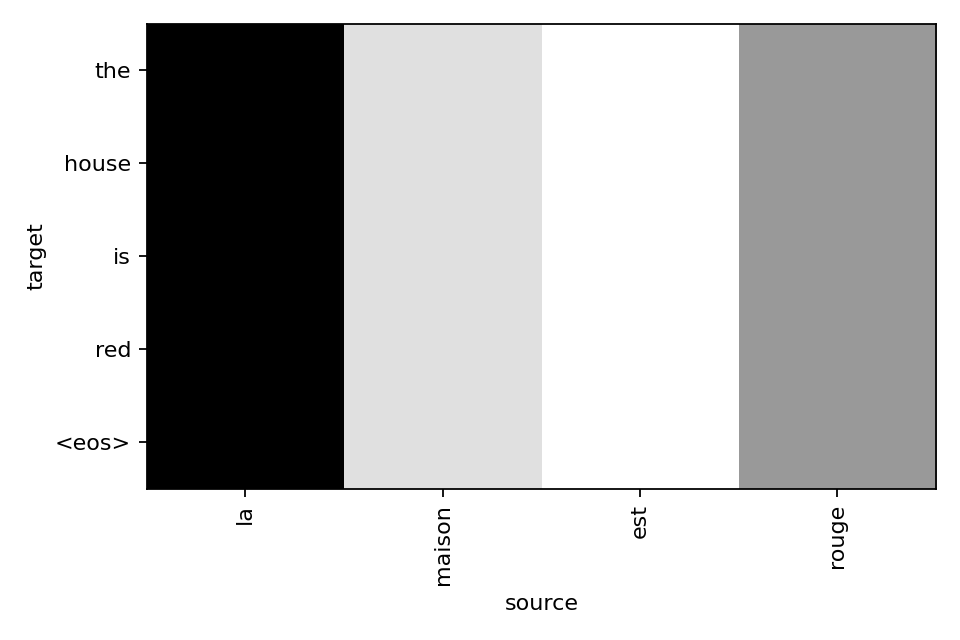

In [5]:
SENTENCE = "la maison est rouge"
ATTENTION_PATH = f"{TINY_SAVE_DIR}/attention_la_maison_est_rouge.png"

run_cmd([
    sys.executable, "-m", "rnnsearch.translate",
    "--checkpoint", f"{TINY_SAVE_DIR}/best.pt",
    "--sentence", SENTENCE,
    "--beam-size", "3",
    "--device", TINY_DEVICE,
    "--attention-png", ATTENTION_PATH,
])

from IPython.display import Image, display

attention_file = PROJECT_DIR / ATTENTION_PATH
if attention_file.exists():
    display(Image(filename=str(attention_file)))


## 6. Evaluate French-to-English BLEU

Evaluates the trained French-to-English checkpoint on the reversed tiny test split and writes predictions.


In [6]:
run_cmd([
    sys.executable, "-m", "rnnsearch.evaluate",
    "--checkpoint", f"{TINY_SAVE_DIR}/best.pt",
    "--test", str((TINY_DATA_DIR / "test.tsv").relative_to(PROJECT_DIR)),
    "--beam-size", "3",
    "--device", TINY_DEVICE,
    "--predictions", f"{TINY_SAVE_DIR}/test.pred.txt",
])

print("\nPredictions:")
print((PROJECT_DIR / TINY_SAVE_DIR / "test.pred.txt").read_text(encoding="utf-8"))


+ /usr/bin/python3 -m rnnsearch.evaluate --checkpoint runs/tiny_fr_en_colab/best.pt --test data/tiny_fr_en/test.tsv --beam-size 3 --device auto --predictions runs/tiny_fr_en_colab/test.pred.txt

Predictions:
he is a student
she likes dogs
the dogs sleep
the house is red



## 7. Batch Inference

Translates a plain-text source file with one sentence per line.


In [7]:
sample_input = PROJECT_DIR / "sample_source_fr.txt"
sample_output = PROJECT_DIR / TINY_SAVE_DIR / "sample_output.txt"
sample_input.write_text("la maison est rouge\nil est un étudiant\n", encoding="utf-8")

run_cmd([
    sys.executable, "-m", "rnnsearch.translate",
    "--checkpoint", f"{TINY_SAVE_DIR}/best.pt",
    "--input", str(sample_input.relative_to(PROJECT_DIR)),
    "--output", str(sample_output.relative_to(PROJECT_DIR)),
    "--beam-size", "3",
    "--device", TINY_DEVICE,
])

print(sample_output.read_text(encoding="utf-8"))


+ /usr/bin/python3 -m rnnsearch.translate --checkpoint runs/tiny_fr_en_colab/best.pt --input sample_source_fr.txt --output runs/tiny_fr_en_colab/sample_output.txt --beam-size 3 --device auto
the house is red
he is a student



## 8. English-to-Bengali Dataset From Hugging Face

Recommended default: `ai4bharat/samanantar`, config `bn`. It is an English-to-Bengali slice of Samanantar with about 8.6M train rows on Hugging Face, natural `src` English and `tgt` Bengali columns, and no official dev/test split. This notebook fetches a bounded sample through the Hugging Face Dataset Viewer API and creates local train/dev/test TSV files.

Alternative: `Helsinki-NLP/opus-100`, config `bn-en`. It has an official Bengali-English train/validation/test setup with 1,000,000 train rows plus 2,000 validation and 2,000 test rows, but the preview includes noisier OPUS/UI/religious text. Set `BN_HF_SOURCE = "opus100"` below if you prefer the standardized split.

The project expects whitespace-tokenized `source<TAB>target` TSV. These cells normalize whitespace and keep the original word-level modeling assumption. Default direction is English to Bengali so you can enter English source text and verify Bengali output; switch `BN_DIRECTION` to `bn_to_en` for the reverse direction.


In [8]:
import json
import time
import urllib.error
import urllib.parse
import urllib.request
from pathlib import Path

BN_HF_SOURCE = "samanantar"  # recommended: "samanantar"; alternative: "opus100"
BN_DIRECTION = "en_to_bn"    # "en_to_bn" or "bn_to_en"
BN_DATA_DIR = PROJECT_DIR / "data" / "hf_bengali_en_bn"

# Bounded defaults for Colab. Increase these for better translation quality.
BN_TRAIN_ROWS = 5000
BN_DEV_ROWS = 500
BN_TEST_ROWS = 500
BN_MAX_SRC_TOKENS = 28
BN_MAX_TGT_TOKENS = 28
BN_PAGE_SIZE = 100
BN_REQUEST_PAUSE_SECONDS = 0.03

BN_SOURCES = {
    "samanantar": {
        "dataset": "ai4bharat/samanantar",
        "config": "bn",
        "train_split": "train",
        "dev_split": "train",
        "test_split": "train",
        "train_start_offset": 0,
        "dev_start_offset": 4_300_000,
        "test_start_offset": 8_400_000,
        "total_train_rows": 8_604_580,
        "notes": "English src / Bengali tgt; train-only on HF, so this notebook creates dev/test from distant train offsets.",
    },
    "opus100": {
        "dataset": "Helsinki-NLP/opus-100",
        "config": "bn-en",
        "train_split": "train",
        "dev_split": "validation",
        "test_split": "test",
        "train_start_offset": 0,
        "dev_start_offset": 0,
        "test_start_offset": 0,
        "total_train_rows": 1_000_000,
        "notes": "Translation dict with bn/en keys and official train/validation/test splits.",
    },
}


def clean_text(text):
    return " ".join(str(text).replace("\t", " ").replace("\n", " ").split())


def extract_en_bn(row, source_name):
    if source_name == "samanantar":
        return clean_text(row["src"]), clean_text(row["tgt"])
    if source_name == "opus100":
        translation = row["translation"]
        return clean_text(translation["en"]), clean_text(translation["bn"])
    raise ValueError(f"unknown source: {source_name}")


def orient_pair(en, bn, direction):
    if direction == "en_to_bn":
        return en, bn
    if direction == "bn_to_en":
        return bn, en
    raise ValueError("BN_DIRECTION must be 'en_to_bn' or 'bn_to_en'")


def valid_pair(src, tgt):
    if not src or not tgt:
        return False
    src_len = len(src.split())
    tgt_len = len(tgt.split())
    return 0 < src_len <= BN_MAX_SRC_TOKENS and 0 < tgt_len <= BN_MAX_TGT_TOKENS


def fetch_rows(dataset, config, split, offset, length, retries=5):
    params = urllib.parse.urlencode({
        "dataset": dataset,
        "config": config,
        "split": split,
        "offset": offset,
        "length": length,
    })
    url = f"https://datasets-server.huggingface.co/rows?{params}"
    transient_statuses = {429, 500, 502, 503, 504}
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=60) as response:
                payload = json.loads(response.read().decode("utf-8"))
            return [item["row"] for item in payload.get("rows", [])]
        except urllib.error.HTTPError as exc:
            if exc.code not in transient_statuses or attempt == retries - 1:
                raise
        except urllib.error.URLError:
            if attempt == retries - 1:
                raise
        time.sleep(min(8.0, 0.5 * (2 ** attempt)))
    return []


def collect_pairs(source_name, split, needed, start_offset):
    source_info = BN_SOURCES[source_name]
    pairs = []
    seen = set()
    offset = start_offset
    pages = 0
    max_pages = max(20, needed // BN_PAGE_SIZE * 8 + 80)

    while len(pairs) < needed and pages < max_pages:
        rows = fetch_rows(source_info["dataset"], source_info["config"], split, offset, BN_PAGE_SIZE)
        if not rows:
            break
        pages += 1
        offset += BN_PAGE_SIZE
        for row in rows:
            en, bn = extract_en_bn(row, source_name)
            src, tgt = orient_pair(en, bn, BN_DIRECTION)
            if not valid_pair(src, tgt):
                continue
            key = (src, tgt)
            if key in seen:
                continue
            seen.add(key)
            pairs.append(key)
            if len(pairs) >= needed:
                break
        if BN_REQUEST_PAUSE_SECONDS:
            time.sleep(BN_REQUEST_PAUSE_SECONDS)

    if len(pairs) < needed:
        raise RuntimeError(
            f"collected {len(pairs)} usable {split} pairs from offset {start_offset}, needed {needed}; "
            "increase token limits, lower requested rows, or choose another source."
        )
    return pairs


def write_tsv(path, pairs):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text("".join(f"{src}\t{tgt}\n" for src, tgt in pairs), encoding="utf-8")


source_info = BN_SOURCES[BN_HF_SOURCE]
BN_DATA_DIR.mkdir(parents=True, exist_ok=True)

train_pairs = collect_pairs(BN_HF_SOURCE, source_info["train_split"], BN_TRAIN_ROWS, source_info["train_start_offset"])
dev_pairs = collect_pairs(BN_HF_SOURCE, source_info["dev_split"], BN_DEV_ROWS, source_info["dev_start_offset"])
test_pairs = collect_pairs(BN_HF_SOURCE, source_info["test_split"], BN_TEST_ROWS, source_info["test_start_offset"])

write_tsv(BN_DATA_DIR / "train.tsv", train_pairs)
write_tsv(BN_DATA_DIR / "dev.tsv", dev_pairs)
write_tsv(BN_DATA_DIR / "test.tsv", test_pairs)

metadata = {
    "hf_source": BN_HF_SOURCE,
    "dataset": source_info["dataset"],
    "config": source_info["config"],
    "direction": BN_DIRECTION,
    "train_rows": len(train_pairs),
    "dev_rows": len(dev_pairs),
    "test_rows": len(test_pairs),
    "max_src_tokens": BN_MAX_SRC_TOKENS,
    "max_tgt_tokens": BN_MAX_TGT_TOKENS,
    "notes": source_info["notes"],
    "sample_train_pairs": train_pairs[:5],
    "sample_test_pairs": test_pairs[:5],
}
(BN_DATA_DIR / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print(json.dumps({k: v for k, v in metadata.items() if not k.startswith("sample_")}, ensure_ascii=False, indent=2))
print("\nSample training pairs:")
for src, tgt in train_pairs[:3]:
    print(f"SRC: {src}\nTGT: {tgt}\n")


{
  "hf_source": "samanantar",
  "dataset": "ai4bharat/samanantar",
  "config": "bn",
  "direction": "en_to_bn",
  "train_rows": 5000,
  "dev_rows": 500,
  "test_rows": 500,
  "max_src_tokens": 28,
  "max_tgt_tokens": 28,
  "notes": "English src / Bengali tgt; train-only on HF, so this notebook creates dev/test from distant train offsets."
}

Sample training pairs:
SRC: The International Civil Aviation Organisation evaluates and ranks airport security systems.
TGT: আন্তর্জাতিক সিভিল এভিয়েশন সংস্থা বিমানবন্দরের নিরাপত্তা, র‌্যাঙ্কিং পর্যালোচনা করে থাকে।

SRC: They can be deactivated using the control panel on your arm.
TGT: আপনার বাহুতে থাকা কন্ট্রোল প্যানেল দ্বারা ঐ জুতাকে অফ করা যাবে।

SRC: He was born at Ulail in Dhaka district of Bengal province in British India (now Dhaka District of Bangladesh).
TGT: আহসানুল হক মোল্লা ব্রিটিশ ভারতের বেঙ্গল প্রেসিডেন্সির (বর্তমান বাংলাদেশ) কুষ্টিয়া জেলার দৌলতপুর উপজেলার তারাগুনিয়া গ্রামে জন্মগ্রহণ করেন।



## 9. Train The English-to-Bengali Model

This trains the same Bahdanau RNNsearch model from scratch on the HF-derived English-to-Bengali TSV files. The defaults are deliberately modest so Colab can run them. For better quality, increase `BN_TRAIN_ROWS`, `BN_EPOCHS`, `BN_MAX_STEPS`, and the model dimensions, then rerun dataset creation and training.


In [9]:
BN_SAVE_DIR = "runs/english_to_bengali_hf_quick"
BN_DEVICE = "auto"
BN_EPOCHS = 8
BN_MAX_STEPS = 1200
BN_BATCH_SIZE = 32

run_cmd([
    sys.executable, "-m", "rnnsearch.train",
    "--train", str((BN_DATA_DIR / "train.tsv").relative_to(PROJECT_DIR)),
    "--dev", str((BN_DATA_DIR / "dev.tsv").relative_to(PROJECT_DIR)),
    "--save-dir", BN_SAVE_DIR,
    "--src-vocab-size", "12000",
    "--tgt-vocab-size", "12000",
    "--min-freq", "1",
    "--emb-dim", "128",
    "--hidden-dim", "128",
    "--align-dim", "128",
    "--maxout-dim", "128",
    "--batch-size", str(BN_BATCH_SIZE),
    "--epochs", str(BN_EPOCHS),
    "--max-steps", str(BN_MAX_STEPS),
    "--report-every", "100",
    "--epoch-report-every", "1",
    "--eval-every", "100",
    "--patience", "6",
    "--device", BN_DEVICE,
])


+ /usr/bin/python3 -m rnnsearch.train --train data/hf_bengali_en_bn/train.tsv --dev data/hf_bengali_en_bn/dev.tsv --save-dir runs/english_to_bengali_hf_quick --src-vocab-size 12000 --tgt-vocab-size 12000 --min-freq 1 --emb-dim 128 --hidden-dim 128 --align-dim 128 --maxout-dim 128 --batch-size 32 --epochs 8 --max-steps 1200 --report-every 100 --epoch-report-every 1 --eval-every 100 --patience 6 --device auto


## 10. English-to-Bengali Inference

Runs beam-search translation from the English-to-Bengali checkpoint. By default it translates the first local test example and prints the reference so you can compare. Set `BN_SENTENCE` to your own English sentence.


In [10]:
from pathlib import Path

metadata = json.loads((BN_DATA_DIR / "metadata.json").read_text(encoding="utf-8"))
BN_CHECKPOINT = PROJECT_DIR / BN_SAVE_DIR / "best.pt"
if not BN_CHECKPOINT.exists():
    BN_CHECKPOINT = PROJECT_DIR / BN_SAVE_DIR / "last.pt"
default_src, default_ref = metadata["sample_test_pairs"][0]

BN_SENTENCE = None  # Example override for en_to_bn: "The school is open today."
sentence = BN_SENTENCE or default_src

print(f"Source ({metadata['direction']}): {sentence}")
if BN_SENTENCE is None:
    print(f"Reference: {default_ref}")
print("Translation:")

run_cmd([
    sys.executable, "-m", "rnnsearch.translate",
    "--checkpoint", str(BN_CHECKPOINT.relative_to(PROJECT_DIR)),
    "--sentence", sentence,
    "--beam-size", "5",
    "--max-len", "80",
    "--device", BN_DEVICE,
    "--disallow-unk",
])


Source (en_to_bn): A report on this was tabled in the Parliament
Reference: এই মর্মে রিপোর্ট লোকসভা পেশ করা হয়ে গিয়েছে।
Translation:
+ /usr/bin/python3 -m rnnsearch.translate --checkpoint runs/english_to_bengali_hf_quick/best.pt --sentence 'A report on this was tabled in the Parliament' --beam-size 5 --max-len 80 --device auto --disallow-unk


## 11. English-to-Bengali Evaluation

Computes tokenized BLEU on the local HF-derived English-to-Bengali test TSV. BLEU will be low for the quick sample; the important check here is that the end-to-end English-to-Bengali train/eval path runs. Larger samples and longer training are required for meaningful quality.


In [11]:
BN_CHECKPOINT = PROJECT_DIR / BN_SAVE_DIR / "best.pt"
if not BN_CHECKPOINT.exists():
    BN_CHECKPOINT = PROJECT_DIR / BN_SAVE_DIR / "last.pt"

run_cmd([
    sys.executable, "-m", "rnnsearch.evaluate",
    "--checkpoint", str(BN_CHECKPOINT.relative_to(PROJECT_DIR)),
    "--test", str((BN_DATA_DIR / "test.tsv").relative_to(PROJECT_DIR)),
    "--beam-size", "5",
    "--max-len", "80",
    "--device", BN_DEVICE,
    "--disallow-unk",
    "--predictions", f"{BN_SAVE_DIR}/test.pred.txt",
])

pred_path = PROJECT_DIR / BN_SAVE_DIR / "test.pred.txt"
print("\nFirst predictions:")
for line in pred_path.read_text(encoding="utf-8").splitlines()[:10]:
    print(line)


+ /usr/bin/python3 -m rnnsearch.evaluate --checkpoint runs/english_to_bengali_hf_quick/best.pt --test data/hf_bengali_en_bn/test.tsv --beam-size 5 --max-len 80 --device auto --disallow-unk --predictions runs/english_to_bengali_hf_quick/test.pred.txt

First predictions:
আমি এই ও

আমি এই
আমি আমি
আমি আমি
আমি আমি
আমি আমি

আমি এই ও
আমি এই ও


## 12. Train On Your Own TSV Data

Prepare UTF-8 TSV files where each line is `source tokens<TAB>target tokens`. Upload them to Colab or place them under `PROJECT_DIR`, then edit the variables below. For WMT-style experiments, start from `configs/paper_like_30.sh` or `configs/paper_like_50.sh`, but expect much longer training.


In [12]:
# Upload or place tokenized TSV files in PROJECT_DIR, then edit these values.
# Format per line: source tokens separated by spaces<TAB>target tokens separated by spaces
RUN_CUSTOM_TRAINING = False
CUSTOM_TRAIN_TSV = "data/tiny/train.tsv"
CUSTOM_DEV_TSV = "data/tiny/dev.tsv"  # set to "" if you do not have dev data
CUSTOM_SAVE_DIR = "runs/custom"
CUSTOM_DEVICE = "auto"

custom_train_cmd = [
    sys.executable, "-m", "rnnsearch.train",
    "--train", CUSTOM_TRAIN_TSV,
    "--save-dir", CUSTOM_SAVE_DIR,
    "--src-vocab-size", "30000",
    "--tgt-vocab-size", "30000",
    "--max-src-len", "50",
    "--max-tgt-len", "50",
    "--emb-dim", "256",
    "--hidden-dim", "512",
    "--align-dim", "512",
    "--maxout-dim", "256",
    "--batch-size", "80",
    "--epochs", "10",
    "--lr", "1.0",
    "--rho", "0.95",
    "--eps", "0.000001",
    "--clip-norm", "1.0",
    "--device", CUSTOM_DEVICE,
]
if CUSTOM_DEV_TSV:
    custom_train_cmd[custom_train_cmd.index("--save-dir"):custom_train_cmd.index("--save-dir")] = ["--dev", CUSTOM_DEV_TSV]

if RUN_CUSTOM_TRAINING:
    run_cmd(custom_train_cmd)
else:
    print("Set RUN_CUSTOM_TRAINING = True after updating CUSTOM_* paths, then run this cell.")


Set RUN_CUSTOM_TRAINING = True after updating CUSTOM_* paths, then run this cell.


## 13. Inference From A Custom Checkpoint

After custom training finishes, point this cell at your checkpoint and sentence.


In [13]:
CUSTOM_CHECKPOINT = PROJECT_DIR / "runs/custom/best.pt"
CUSTOM_SENTENCE = "la maison est rouge"

if CUSTOM_CHECKPOINT.exists():
    run_cmd([
        sys.executable, "-m", "rnnsearch.translate",
        "--checkpoint", str(CUSTOM_CHECKPOINT.relative_to(PROJECT_DIR)),
        "--sentence", CUSTOM_SENTENCE,
        "--beam-size", "5",
        "--device", "auto",
    ])
else:
    print(f"No custom checkpoint yet: {CUSTOM_CHECKPOINT}")


No custom checkpoint yet: /content/bahdanau_rnnsearch/runs/custom/best.pt


## 14. Optional Drive Persistence

Colab VMs are temporary. Use this cell if you want to copy checkpoints to Google Drive.


In [16]:

from google.colab import drive
drive.mount("/content/drive")

DRIVE_RUN_DIR = Path("/content/drive/MyDrive/bahdanau_rnnsearch_runs")
DRIVE_RUN_DIR.mkdir(parents=True, exist_ok=True)
drive_target = DRIVE_RUN_DIR / Path(TINY_SAVE_DIR).name
shutil.copytree(PROJECT_DIR / TINY_SAVE_DIR, drive_target, dirs_exist_ok=True)
print(f"Copied run artifacts to {drive_target}")


Mounted at /content/drive
Copied run artifacts to /content/drive/MyDrive/bahdanau_rnnsearch_runs/tiny_fr_en_colab
